<a href="https://colab.research.google.com/github/jacunda/POS-DATASCIENCE-IA/blob/main/notebook_final_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo de Trading com Deep Learning e Indicadores Fibonacci

**Instituicao:** FIAP MBA - Deep Learning  
**Cliente:** QuantumFinance (ficticio)  
**Acoes Analisadas:** VALE3, PETR4, BBAS3, CSNA3  
**Periodo dos Dados:** Janeiro/2000 a Dezembro/2023  
**Framework:** TensorFlow / Keras  

---

## Objetivo

Desenvolver modelos de deep learning baseados em **LSTM** (Long Short-Term Memory) que preveem sinais de **compra (+1)** e **venda (-1)** para acoes brasileiras, utilizando os ultimos 15 dias de comportamento de precos como entrada.

O modelo emprega **engenharia de features baseada em Fibonacci**, incorporando niveis de retracamento, razao aurea e indicadores tecnicos classicos (RSI, MACD, Bollinger Bands) para gerar 49 features por amostra.

## Estrutura do Notebook

1. Configuracao e Imports
2. Carregamento e Exploracao dos Dados
3. Engenharia de Features Fibonacci
4. Arquitetura e Treinamento do Modelo LSTM
5. Validacao Cruzada Temporal (K-Fold)
6. Backtesting Financeiro
7. Ensemble de Modelos
8. Analise Comparativa Detalhada
9. Resultados Consolidados e Conclusoes

## 1. Imports e Configuracao GPU

Importamos todas as bibliotecas necessarias e configuramos a GPU para treinamento acelerado com mixed precision (FP16/FP32).

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Configuracao GPU
def configure_gpu():
    """Configura TensorFlow para uso eficiente da GPU."""
    gpus = tf.config.list_physical_devices('GPU')

    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            tf.config.set_visible_devices(gpus, 'GPU')
            logical_gpus = tf.config.list_logical_devices('GPU')
            print(f"GPUs Fisicas: {len(gpus)}")
            print(f"GPUs Logicas: {len(logical_gpus)}")
            for i, gpu in enumerate(gpus):
                print(f"  GPU {i}: {gpu.name}")
            print(f"CUDA disponivel: {tf.test.is_built_with_cuda()}")
            # Mixed precision para treinamento mais rapido em GPUs RTX
            policy = tf.keras.mixed_precision.Policy('mixed_float16')
            tf.keras.mixed_precision.set_global_policy(policy)
            print("Mixed precision: Habilitado (FP16/FP32)")
            return True
        except RuntimeError as e:
            print(f"Erro na configuracao GPU: {e}")
            return False
    else:
        print("AVISO: Nenhuma GPU detectada - usando CPU")
        print("O treinamento sera significativamente mais lento")
        return False

GPU_AVAILABLE = configure_gpu()

# Seeds para reprodutibilidade
np.random.seed(42)
tf.random.set_seed(42)

print(f"\nTensorFlow versao: {tf.__version__}")
print(f"GPU disponivel: {GPU_AVAILABLE}")

GPUs Fisicas: 1
GPUs Logicas: 1
  GPU 0: /physical_device:GPU:0
CUDA disponivel: True
Mixed precision: Habilitado (FP16/FP32)

TensorFlow versao: 2.19.0
GPU disponivel: True


## 1.1 Download dos Dados do Google Drive

Os dados do projeto estao hospedados em uma pasta compartilhada no Google Drive. A celula abaixo faz o download automatico dos CSVs para o diretorio `data/`.

**No Google Colab:** O `gdown` ja vem pre-instalado. Basta executar a celula abaixo.

**Em ambiente local:** O `gdown` sera instalado automaticamente se necessario.

In [ ]:
import subprocess
import sys
import shutil

# ============================================================
# CONFIGURACAO - Google Drive
# ============================================================
# Pasta compartilhada com os CSVs de treino e teste
GDRIVE_FOLDER_ID = '1qTs6jMk5spDP9wWS8PpEonFMmTIL30e8'

DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

EXPECTED_FILES = [
    'vale3_treino.csv', 'vale3_teste.csv',
    'petr4_treino.csv', 'petr4_teste.csv',
    'bbas3_treino.csv', 'bbas3_teste.csv',
    'csna3_treino.csv', 'csna3_teste.csv'
]

def check_local_data():
    """Verifica se os dados ja existem localmente."""
    missing = [f for f in EXPECTED_FILES if not os.path.exists(os.path.join(DATA_DIR, f))]
    return len(missing) == 0, missing

def download_from_gdrive(folder_id):
    """Baixa dados do Google Drive usando gdown."""
    try:
        import gdown
    except ImportError:
        print("Instalando gdown...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'])
        import gdown

    print(f"Baixando dados do Google Drive (folder: {folder_id})...")
    url = f'https://drive.google.com/drive/folders/{folder_id}'

    try:
        gdown.download_folder(url, output=DATA_DIR, quiet=False, use_cookies=False, remaining_ok=True)

        # gdown pode criar subpastas - mover arquivos para data/ se necessario
        for root, dirs, files in os.walk(DATA_DIR):
            if root != DATA_DIR:
                for f in files:
                    src = os.path.join(root, f)
                    dst = os.path.join(DATA_DIR, f)
                    if not os.path.exists(dst):
                        shutil.move(src, dst)
                        print(f"  Movido: {f}")
        # Limpar subpastas vazias
        for root, dirs, files in os.walk(DATA_DIR, topdown=False):
            if root != DATA_DIR and not os.listdir(root):
                os.rmdir(root)

        print("Download concluido!")
        return True
    except Exception as e:
        print(f"Erro no download: {e}")
        return False

# ============================================================
# EXECUCAO
# ============================================================
data_exists, missing_files = check_local_data()

if data_exists:
    print(f"Dados ja existem em '{DATA_DIR}/' ({len(EXPECTED_FILES)} arquivos)")
else:
    print(f"Arquivos faltando: {len(missing_files)}")
    success = download_from_gdrive(GDRIVE_FOLDER_ID)
    if success:
        data_exists, missing_files = check_local_data()
        if data_exists:
            print("\nTodos os arquivos baixados com sucesso!")
        else:
            print(f"\nATENCAO: Arquivos faltando apos download: {missing_files}")
    else:
        print("\nFalha no download. Faca upload manual dos CSVs para a pasta 'data/'")

# Listar arquivos
print(f"\nArquivos em '{DATA_DIR}/':")
if os.path.exists(DATA_DIR):
    for f in sorted(os.listdir(DATA_DIR)):
        if f.endswith('.csv'):
            size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024*1024)
            print(f"  {f} ({size_mb:.2f} MB)")

Arquivos faltando: 8
Baixando dados do Google Drive (folder: 1qTs6jMk5spDP9wWS8PpEonFMmTIL30e8)...


Retrieving folder contents


Processing file 1qH-U-w497k8lxNF6FRraRjruWJfBlogG bbas3_teste.csv
Processing file 1cUCeczX4vDtGZWKZ08vETYwmIOPXh0sO bbas3_treino.csv
Processing file 10FLIvxbEfErTPqSYdjcMQS7V7-JreVy3 csna3_teste.csv
Processing file 1P5ZrS4tmsoaQxanWIIJD6swQawBjdzRs csna3_treino.csv
Processing file 1Sfzj4bvS-flfnpQsYBcsnv517f4IVahc petr4_teste.csv
Processing file 1bEvro8q2MfwS00SzzPmwTRBrTbuvcaCF petr4_treino.csv
Processing file 1tsnuasbz6ReMm7MnwZT2UcwewUL8yWHq vale3_teste.csv
Processing file 1ZpHksY9b8dulqpdV8RMzpDX7YHlwFTmC vale3_treino.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1qH-U-w497k8lxNF6FRraRjruWJfBlogG
To: /content/data/bbas3_teste.csv
100%|██████████| 393k/393k [00:00<00:00, 6.07MB/s]
Downloading...
From: https://drive.google.com/uc?id=1cUCeczX4vDtGZWKZ08vETYwmIOPXh0sO
To: /content/data/bbas3_treino.csv
100%|██████████| 1.58M/1.58M [00:00<00:00, 13.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=10FLIvxbEfErTPqSYdjcMQS7V7-JreVy3
To: /content/data/csna3_teste.csv
100%|██████████| 396k/396k [00:00<00:00, 5.88MB/s]
Downloading...
From: https://drive.google.com/uc?id=1P5ZrS4tmsoaQxanWIIJD6swQawBjdzRs
To: /content/data/csna3_treino.csv
100%|██████████| 1.57M/1.57M [00:00<00:00, 12.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Sfzj4bvS-flfnpQsYBcsnv517f4IVahc
To: /content/data/petr4_teste.csv
100%|██████████| 398k/398k [00:00<00:00, 5.95MB/s]
Downloading...
From: https://drive

Download concluido!

Todos os arquivos baixados com sucesso!

Arquivos em 'data/':
  bbas3_teste.csv (0.37 MB)
  bbas3_treino.csv (1.51 MB)
  csna3_teste.csv (0.38 MB)
  csna3_treino.csv (1.49 MB)
  petr4_teste.csv (0.38 MB)
  petr4_treino.csv (1.51 MB)
  vale3_teste.csv (0.37 MB)
  vale3_treino.csv (1.53 MB)



Download completed


## 2. Descricao e Carregamento dos Dados

### Estrutura dos CSVs

Cada acao possui dois arquivos CSV no diretorio `data/`:
- `{ticker}_treino.csv` - Dados de treinamento (Jan/2000 a meados de 2019)
- `{ticker}_teste.csv` - Dados de teste (meados de 2019 a Dez/2023)

### Colunas

| Coluna | Descricao |
|--------|----------|
| `Date` | Dia de negociacao |
| `Close` | Preco de fechamento real |
| `Smoothed_Close` | Preco de fechamento suavizado (tecnica confidencial) |
| `Label` | Variavel alvo: `+1` (compra) ou `-1` (venda) |
| `Past_1_Days_Close` a `Past_15_Days_Close` | Precos historicos para features |

### Labels
- **Compra (+1):** Tendencia de alta (pontos verdes nas visualizacoes)
- **Venda (-1):** Tendencia de baixa (pontos vermelhos)
- Labels sao baseados nos precos suavizados, nao nos precos brutos

### Split Temporal
- **Treinamento:** 2000-01 a ~2019-06
- **Teste:** ~2019-06 a 2023-12
- **Sem embaralhamento** - dados temporais devem manter ordem cronologica

In [ ]:
# Acoes a serem analisadas
STOCKS = ['VALE3', 'PETR4', 'BBAS3', 'CSNA3']
DATA_DIR = 'data'

# Carregar todos os dados
data = {}
for stock in STOCKS:
    ticker = stock.lower()
    df_train = pd.read_csv(os.path.join(DATA_DIR, f'{ticker}_treino.csv'), index_col=0)
    df_test = pd.read_csv(os.path.join(DATA_DIR, f'{ticker}_teste.csv'), index_col=0)
    data[stock] = {'train': df_train, 'test': df_test}

    print(f"\n{'='*60}")
    print(f"{stock}")
    print(f"{'='*60}")
    print(f"Treino: {len(df_train)} amostras ({df_train.index[0]} a {df_train.index[-1]})")
    print(f"Teste:  {len(df_test)} amostras ({df_test.index[0]} a {df_test.index[-1]})")
    print(f"\nDistribuicao de Labels (Treino):")
    label_counts = df_train['Label'].value_counts()
    for label, count in label_counts.items():
        pct = count / len(df_train) * 100
        nome = 'Compra' if label == 1 else 'Venda'
        print(f"  {nome} ({label:+d}): {count} ({pct:.1f}%)")


VALE3
Treino: 4808 amostras (1 a 4808)
Teste:  1203 amostras (4809 a 6011)

Distribuicao de Labels (Treino):
  Venda (-1): 2716 (56.5%)
  Compra (+1): 2092 (43.5%)

PETR4
Treino: 4808 amostras (1 a 4808)
Teste:  1203 amostras (4809 a 6011)

Distribuicao de Labels (Treino):
  Venda (-1): 2654 (55.2%)
  Compra (+1): 2154 (44.8%)

BBAS3
Treino: 4735 amostras (1 a 4735)
Teste:  1185 amostras (4736 a 5920)

Distribuicao de Labels (Treino):
  Venda (-1): 2602 (55.0%)
  Compra (+1): 2133 (45.0%)

CSNA3
Treino: 4743 amostras (1 a 4743)
Teste:  1186 amostras (4744 a 5929)

Distribuicao de Labels (Treino):
  Venda (-1): 2655 (56.0%)
  Compra (+1): 2088 (44.0%)


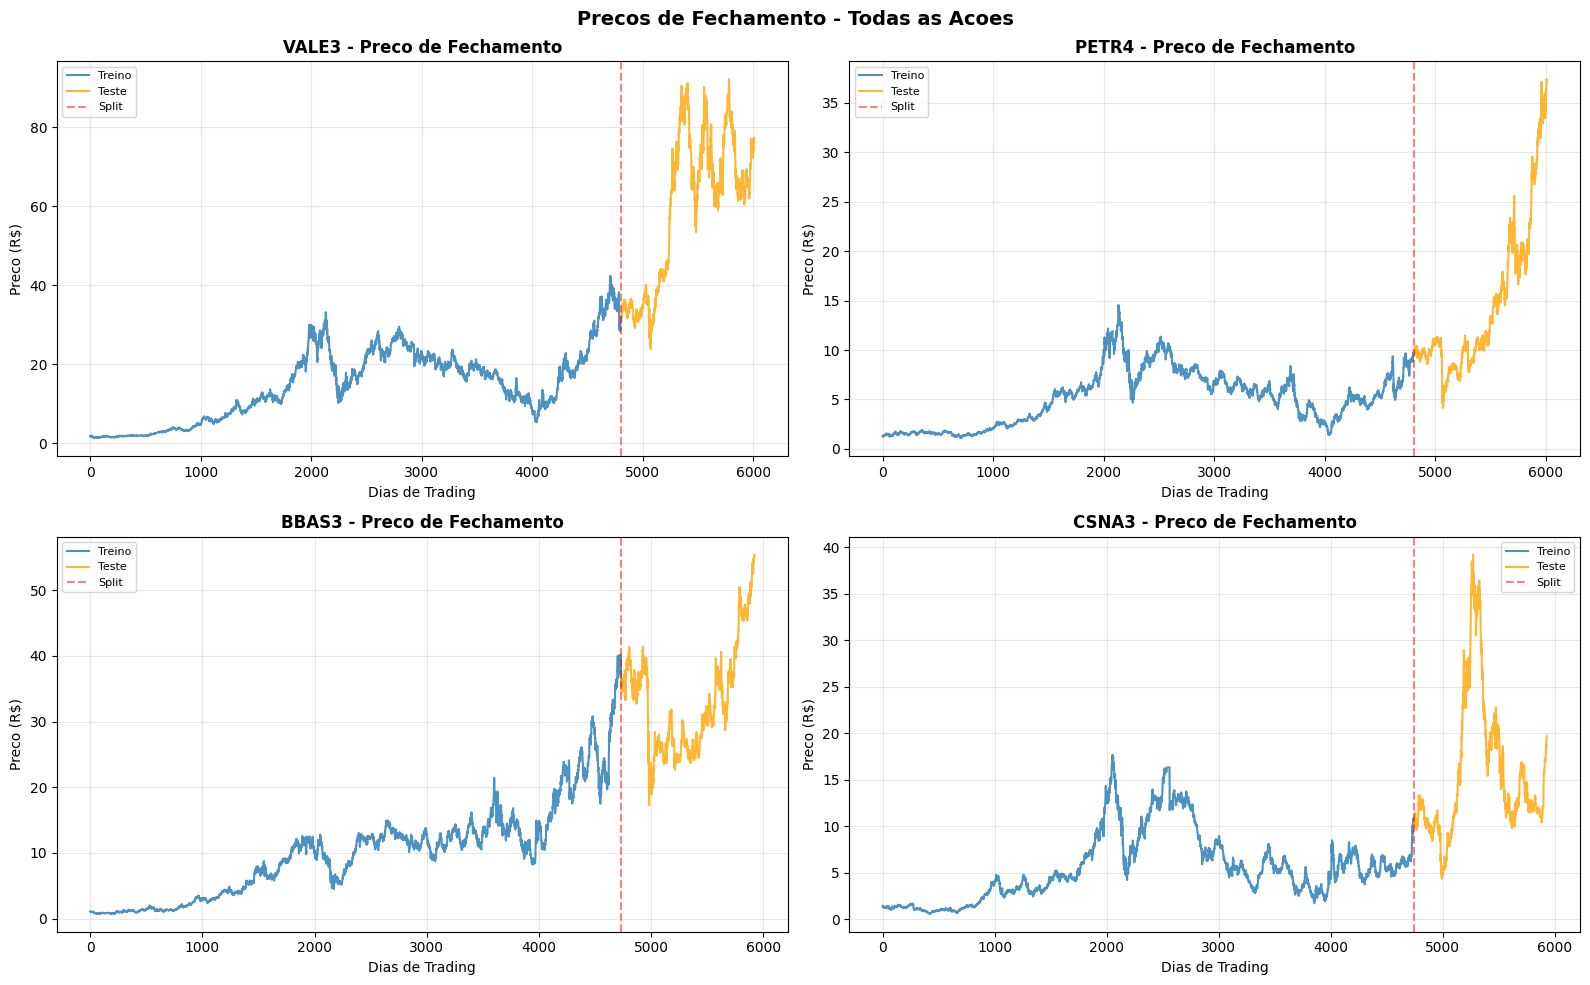

In [ ]:
# Visualizacao dos precos de fechamento
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, stock in enumerate(STOCKS):
    ax = axes[i]
    df_train = data[stock]['train']
    df_test = data[stock]['test']

    ax.plot(range(len(df_train)), df_train['Close'].values, label='Treino', alpha=0.8)
    ax.plot(range(len(df_train), len(df_train) + len(df_test)),
            df_test['Close'].values, label='Teste', alpha=0.8, color='orange')
    ax.axvline(x=len(df_train), color='red', linestyle='--', alpha=0.5, label='Split')
    ax.set_title(f'{stock} - Preco de Fechamento', fontsize=12, fontweight='bold')
    ax.set_xlabel('Dias de Trading')
    ax.set_ylabel('Preco (R$)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Precos de Fechamento - Todas as Acoes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Primeiras linhas de um dataset de exemplo
print("Exemplo de dados - CSNA3 (Treino):")
print(data['CSNA3']['train'].head())
print(f"\nColunas: {list(data['CSNA3']['train'].columns)}")

Exemplo de dados - CSNA3 (Treino):
         Date     Close  Smoothed_Close  Label  Past_1_Days_Close  \
1  2000-01-24  1.409986        1.588954     -1           1.375888   
2  2000-01-26  1.398052        1.569864     -1           1.409986   
3  2000-01-27  1.375888        1.550466     -1           1.398052   
4  2000-01-28  1.363953        1.531815     -1           1.375888   
5  2000-01-31  1.329854        1.511619     -1           1.363953   

   Past_2_Days_Close  Past_3_Days_Close  Past_4_Days_Close  Past_5_Days_Close  \
1           1.478184           1.522513           1.566841           1.594120   
2           1.375888           1.478184           1.522513           1.566841   
3           1.409986           1.375888           1.478184           1.522513   
4           1.398052           1.409986           1.375888           1.478184   
5           1.375888           1.398052           1.409986           1.375888   

   Past_6_Days_Close  Past_7_Days_Close  Past_8_Days_Close  Pas

## 3. Engenharia de Features Fibonacci

### Conceito

A sequencia de Fibonacci e amplamente utilizada em analise tecnica de mercados financeiros. Os niveis de retracamento de Fibonacci (23.6%, 38.2%, 50.0%, 61.8%, 100%, 161.8%) sao usados para identificar possiveis niveis de suporte e resistencia.

### Features Geradas (49 no total)

| Grupo | Qtd | Descricao |
|-------|-----|----------|
| Precos normalizados | 15 | Past_1 a Past_15 normalizados (z-score) |
| Retornos diarios | 15 | Variacao percentual entre dias consecutivos |
| Distancias Fibonacci | 7 | Distancia do preco atual a cada nivel de retracamento |
| Momentum Fibonacci | 1 | Media movel ponderada por pesos Fibonacci |
| Oscilador Razao Aurea | 1 | Diferenca entre MAs de periodos 5 e 8 (Fibonacci) |
| Suporte/Resistencia | 2 | Distancia ao suporte e resistencia Fibonacci mais proximos |
| Volatilidade | 1 | Desvio padrao dos retornos |
| Momentum de Preco | 1 | Taxa de variacao ao longo de 15 dias |
| Razao High/Low | 1 | Amplitude normalizada do periodo |
| RSI | 1 | Indice de Forca Relativa (normalizado 0-1) |
| MACD | 2 | MACD e sinal com periodos Fibonacci (8, 13) |
| Bollinger Bands | 2 | Distancia as bandas superior e inferior |
| **Total** | **49** | |

In [ ]:
class FibonacciFeatureEngine:
    """
    Motor de engenharia de features usando razoes e niveis de retracamento Fibonacci.
    Gera 49 features a partir de uma janela de 15 precos.
    """

    # Niveis Fibonacci usados em trading
    FIBONACCI_LEVELS = [0.0, 0.236, 0.382, 0.500, 0.618, 1.0, 1.618]
    GOLDEN_RATIO = 1.618033988749895

    @staticmethod
    def calculate_fibonacci_retracements(prices):
        """Calcula niveis de retracamento Fibonacci baseado no high/low do periodo."""
        high = np.max(prices)
        low = np.min(prices)
        diff = high - low

        if diff == 0:
            return {level: high for level in FibonacciFeatureEngine.FIBONACCI_LEVELS}

        levels = {}
        for fib in FibonacciFeatureEngine.FIBONACCI_LEVELS:
            levels[fib] = high - (diff * fib)

        return levels

    @staticmethod
    def calculate_distance_to_fibonacci(current_price, fib_levels):
        """Calcula distancia normalizada do preco atual a cada nivel Fibonacci."""
        distances = []
        for level_value in fib_levels.values():
            if level_value != 0:
                distance = (current_price - level_value) / level_value
            else:
                distance = 0
            distances.append(distance)
        return distances

    @staticmethod
    def calculate_fibonacci_momentum(prices):
        """Calcula momentum usando media movel ponderada pela sequencia Fibonacci."""
        if len(prices) < 5:
            return 0.0

        fib_weights = [1, 1, 2, 3, 5, 8, 13]
        weights = fib_weights[:min(len(prices), len(fib_weights))]
        weights = np.array(weights[-len(prices):])
        weights = weights / weights.sum()

        weighted_avg = np.average(prices[-len(weights):], weights=weights)
        current = prices[-1]

        if weighted_avg != 0:
            return (current - weighted_avg) / weighted_avg
        return 0.0

    @staticmethod
    def calculate_golden_ratio_oscillator(prices):
        """Calcula oscilador baseado em periodos da razao aurea."""
        if len(prices) < 8:
            return 0.0

        short_period = min(5, len(prices))
        long_period = min(8, len(prices))

        short_ma = np.mean(prices[-short_period:])
        long_ma = np.mean(prices[-long_period:])

        if long_ma != 0:
            return (short_ma - long_ma) / long_ma
        return 0.0

    @staticmethod
    def find_nearest_fibonacci_support_resistance(current_price, fib_levels):
        """Encontra os niveis Fibonacci de suporte e resistencia mais proximos."""
        sorted_levels = sorted(fib_levels.values())

        support = None
        resistance = None

        for level in sorted_levels:
            if level < current_price:
                support = level
            elif level > current_price and resistance is None:
                resistance = level
                break

        support_distance = (current_price - support) / current_price if support else 0
        resistance_distance = (resistance - current_price) / current_price if resistance else 0

        return support_distance, resistance_distance

    @staticmethod
    def calculate_rsi(prices, period=14):
        """Calcula o Indice de Forca Relativa (RSI)."""
        if len(prices) < period + 1:
            return 50.0

        deltas = np.diff(prices)
        gains = np.where(deltas > 0, deltas, 0)
        losses = np.where(deltas < 0, -deltas, 0)

        avg_gain = np.mean(gains[-period:]) if len(gains) >= period else 0
        avg_loss = np.mean(losses[-period:]) if len(losses) >= period else 0

        if avg_loss == 0:
            return 100.0

        rs = avg_gain / avg_loss
        rsi = 100 - (100 / (1 + rs))
        return rsi

    @staticmethod
    def calculate_macd(prices):
        """Calcula MACD com periodos Fibonacci (8 e 13)."""
        if len(prices) < 13:
            return 0.0, 0.0

        ema_short = np.mean(prices[-8:])
        ema_long = np.mean(prices[-13:]) if len(prices) >= 13 else np.mean(prices)

        macd = ema_short - ema_long
        signal = macd * 0.618  # Suavizacao pela razao aurea

        return macd / (np.mean(prices) + 1e-8), signal / (np.mean(prices) + 1e-8)

    @staticmethod
    def calculate_bollinger_bands(prices, period=14, num_std=2):
        """Calcula Bandas de Bollinger."""
        if len(prices) < period:
            period = len(prices)

        recent_prices = prices[-period:]
        sma = np.mean(recent_prices)
        std = np.std(recent_prices)

        upper_band = sma + (num_std * std)
        lower_band = sma - (num_std * std)

        current = prices[-1]

        bb_upper = (upper_band - current) / (current + 1e-8)
        bb_lower = (current - lower_band) / (current + 1e-8)

        return bb_upper, bb_lower

    @classmethod
    def engineer_features(cls, price_window):
        """
        Metodo principal: gera todas as 49 features Fibonacci a partir de uma janela de 15 precos.
        """
        features = []

        # 1. Precos normalizados (15 features)
        prices_normalized = (price_window - price_window.mean()) / (price_window.std() + 1e-8)
        features.extend(prices_normalized)

        # 2. Retornos diarios (15 features, incluindo padding)
        returns = np.diff(price_window) / (price_window[:-1] + 1e-8)
        features.extend(returns)
        features.append(0)  # Padding

        # 3. Niveis de retracamento Fibonacci
        fib_levels = cls.calculate_fibonacci_retracements(price_window)
        current_price = price_window[-1]

        # 4. Distancia a cada nivel Fibonacci (7 features)
        distances = cls.calculate_distance_to_fibonacci(current_price, fib_levels)
        features.extend(distances)

        # 5. Momentum Fibonacci (1 feature)
        fib_momentum = cls.calculate_fibonacci_momentum(price_window)
        features.append(fib_momentum)

        # 6. Oscilador da razao aurea (1 feature)
        golden_osc = cls.calculate_golden_ratio_oscillator(price_window)
        features.append(golden_osc)

        # 7. Distancias de suporte/resistencia (2 features)
        support_dist, resistance_dist = cls.find_nearest_fibonacci_support_resistance(
            current_price, fib_levels
        )
        features.extend([support_dist, resistance_dist])

        # 8. Volatilidade (1 feature)
        volatility = np.std(returns) if len(returns) > 0 else 0
        features.append(volatility)

        # 9. Momentum de preco (1 feature)
        momentum = (price_window[-1] - price_window[0]) / (price_window[0] + 1e-8)
        features.append(momentum)

        # 10. Razao high/low Fibonacci (1 feature)
        high_low_ratio = (np.max(price_window) - np.min(price_window)) / (np.mean(price_window) + 1e-8)
        features.append(high_low_ratio)

        # 11. RSI (1 feature)
        rsi = cls.calculate_rsi(price_window, period=14)
        features.append(rsi / 100.0)

        # 12. MACD (2 features)
        macd, macd_signal = cls.calculate_macd(price_window)
        features.extend([macd, macd_signal])

        # 13. Bollinger Bands (2 features)
        bb_upper, bb_lower = cls.calculate_bollinger_bands(price_window)
        features.extend([bb_upper, bb_lower])

        return np.array(features)

In [ ]:
# Demonstracao: aplicar engenharia de features em uma janela de exemplo
df_example = data['CSNA3']['train']
feature_cols = [f'Past_{i}_Days_Close' for i in range(15, 0, -1)]
sample_window = df_example[feature_cols].iloc[100].values

print(f"Janela de precos (15 dias): {sample_window}")
print(f"Preco mais antigo (Past_15): R$ {sample_window[0]:.2f}")
print(f"Preco mais recente (Past_1): R$ {sample_window[-1]:.2f}")

# Gerar features
features = FibonacciFeatureEngine.engineer_features(sample_window)
print(f"\nTotal de features geradas: {len(features)}")

# Nomes das features
feature_names = (
    [f'Preco_Norm_{i}' for i in range(1, 16)] +
    [f'Retorno_{i}' for i in range(1, 16)] +
    [f'Dist_Fib_{level}' for level in FibonacciFeatureEngine.FIBONACCI_LEVELS] +
    ['Momentum_Fib', 'Osc_Razao_Aurea', 'Dist_Suporte', 'Dist_Resistencia',
     'Volatilidade', 'Momentum_Preco', 'Razao_HighLow', 'RSI',
     'MACD', 'MACD_Sinal', 'BB_Superior', 'BB_Inferior']
)

print(f"\nFeatures detalhadas:")
for name, value in zip(feature_names, features):
    print(f"  {name:25s}: {value:+.6f}")

Janela de precos (15 dias): [1.27359104 1.37588775 1.36395299 1.33837879 1.29575503 1.24972153
 1.23949182 1.24972153 1.28382075 1.28041041 1.27359104 1.24631166
 1.18152452 1.1116215  1.15935969]
Preco mais antigo (Past_15): R$ 1.27
Preco mais recente (Past_1): R$ 1.16

Total de features geradas: 49

Features detalhadas:
  Preco_Norm_1             : +0.173785
  Preco_Norm_2             : +1.649308
  Preco_Norm_3             : +1.477162
  Preco_Norm_4             : +1.108280
  Preco_Norm_5             : +0.493477
  Preco_Norm_6             : -0.170508
  Preco_Norm_7             : -0.318060
  Preco_Norm_8             : -0.170508
  Preco_Norm_9             : +0.321338
  Preco_Norm_10            : +0.272147
  Preco_Norm_11            : +0.173785
  Preco_Norm_12            : -0.219691
  Preco_Norm_13            : -1.154178
  Preco_Norm_14            : -2.162456
  Preco_Norm_15            : -1.473882
  Retorno_1                : +0.080321
  Retorno_2                : -0.008674
  Retorno_3  

## 4. Arquitetura do Modelo LSTM

### Arquitetura Inspirada em Fibonacci

O modelo usa numeros da sequencia de Fibonacci para definir o tamanho das camadas:

```
Input (49 features)
  -> LSTM(89) + Dropout(0.4) + BatchNorm
  -> LSTM(55) + Dropout(0.4) + BatchNorm
  -> LSTM(34) + Dropout(0.4) + BatchNorm
  -> Dense(21) + Dropout(0.3)
  -> Dense(13) + Dropout(0.3)
  -> Dense(8)
  -> Dense(1, sigmoid)  # Saida: probabilidade de compra
```

### Decisoes de Design

- **Dropout alto (40%):** Combate overfitting em dados financeiros ruidosos
- **Regularizacao L2 (0.001):** Penaliza pesos grandes para generalizacao
- **BatchNormalization:** Estabiliza e acelera treinamento
- **ReduceLROnPlateau com fator 0.618:** Razao aurea para reducao do learning rate
- **Class weights:** Balanceia classes desiguais de compra/venda
- **Mixed precision (FP16):** Treinamento ~2-3x mais rapido em GPUs RTX

In [ ]:
class StockTradingModel:
    """
    Modelo LSTM para trading de acoes com features Fibonacci.
    """

    def __init__(self, stock_name='VALE3', use_fibonacci=True):
        self.stock_name = stock_name
        self.use_fibonacci = use_fibonacci
        self.model = None
        self.scaler = StandardScaler()
        self.history = None

    def load_data(self, data_dir='data'):
        """Carrega dados de treino e teste."""
        ticker = self.stock_name.lower()
        train_file = os.path.join(data_dir, f'{ticker}_treino.csv')
        test_file = os.path.join(data_dir, f'{ticker}_teste.csv')

        self.df_train = pd.read_csv(train_file, index_col=0)
        self.df_test = pd.read_csv(test_file, index_col=0)

        print(f"Dados carregados para {self.stock_name}:")
        print(f"  Treino: {len(self.df_train)} amostras")
        print(f"  Teste: {len(self.df_test)} amostras")
        print(f"  Distribuicao (treino): {dict(self.df_train['Label'].value_counts())}")

    def prepare_features(self, df):
        """Extrai e prepara features do dataframe."""
        feature_cols = [f'Past_{i}_Days_Close' for i in range(15, 0, -1)]
        price_windows = df[feature_cols].values

        if self.use_fibonacci:
            features_list = []
            for i, window in enumerate(price_windows):
                if i % 1000 == 0:
                    print(f"  Processando features: {i}/{len(price_windows)}", end='\r')
                features = FibonacciFeatureEngine.engineer_features(window)
                features_list.append(features)
            print(f"  Features processadas: {len(price_windows)} amostras")
            X = np.array(features_list)
        else:
            X = price_windows

        # Labels: converter -1, 1 para 0, 1 (classificacao binaria)
        y = (df['Label'].values + 1) // 2

        return X, y

    def build_model(self, input_shape):
        """
        Constroi modelo LSTM com arquitetura inspirada em Fibonacci.
        Camadas: 89, 55, 34, 21, 13, 8 (numeros Fibonacci)
        """
        model = keras.Sequential([
            layers.Input(shape=input_shape),

            # Primeiro bloco LSTM - 89 unidades
            layers.LSTM(89, return_sequences=True,
                       kernel_regularizer=keras.regularizers.l2(0.001)),
            layers.Dropout(0.4),
            layers.BatchNormalization(),

            # Segundo bloco LSTM - 55 unidades
            layers.LSTM(55, return_sequences=True,
                       kernel_regularizer=keras.regularizers.l2(0.001)),
            layers.Dropout(0.4),
            layers.BatchNormalization(),

            # Terceiro bloco LSTM - 34 unidades
            layers.LSTM(34, return_sequences=False,
                       kernel_regularizer=keras.regularizers.l2(0.001)),
            layers.Dropout(0.4),
            layers.BatchNormalization(),

            # Camadas Dense com neuronios Fibonacci
            layers.Dense(21, activation='relu',
                        kernel_regularizer=keras.regularizers.l2(0.001)),
            layers.Dropout(0.3),

            layers.Dense(13, activation='relu',
                        kernel_regularizer=keras.regularizers.l2(0.001)),
            layers.Dropout(0.3),

            layers.Dense(8, activation='relu'),

            # Saida (float32 para estabilidade numerica com mixed precision)
            layers.Dense(1, activation='sigmoid', dtype='float32')
        ])

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
        )

        self.model = model
        return model

    def train(self, epochs=50, batch_size=64, validation_split=0.2):
        """Treina o modelo com callbacks otimizados."""
        print(f"\nPreparando dados de treinamento para {self.stock_name}...")

        X_train, y_train = self.prepare_features(self.df_train)

        # Normalizar features
        X_train_scaled = self.scaler.fit_transform(X_train)

        # Reshape para LSTM: (amostras, timesteps, features)
        n_samples = X_train_scaled.shape[0]
        n_features = X_train_scaled.shape[1]
        X_train_reshaped = X_train_scaled.reshape(n_samples, n_features, 1)

        print(f"  Total de features: {n_features}")

        # Construir modelo
        self.build_model(input_shape=(n_features, 1))

        # Callbacks
        early_stop = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        )

        reduce_lr = callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.618,  # Fator da razao aurea
            patience=5,
            min_lr=1e-7,
            verbose=1
        )

        # Pesos de classe para dados desbalanceados
        class_counts = np.bincount(y_train)
        total = len(y_train)
        class_weight = {
            0: total / (2 * class_counts[0]),
            1: total / (2 * class_counts[1])
        }

        print(f"  Pesos de classe: {class_weight}")
        print(f"  Epochs: {epochs} (max), Batch size: {batch_size}")
        print(f"  Dispositivo: {'GPU (CUDA)' if GPU_AVAILABLE else 'CPU'}")

        # Treinar
        self.history = self.model.fit(
            X_train_reshaped, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            class_weight=class_weight,
            callbacks=[early_stop, reduce_lr],
            verbose=1
        )

        return self.history

    def evaluate(self):
        """Avalia modelo no conjunto de teste."""
        print(f"\nAvaliando {self.stock_name} no conjunto de teste...")

        X_test, y_test = self.prepare_features(self.df_test)

        # Normalizar com scaler do treino
        X_test_scaled = self.scaler.transform(X_test)
        X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0],
                                                  X_test_scaled.shape[1], 1)

        # Predicoes
        y_pred_proba = self.model.predict(X_test_reshaped, verbose=0)
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()

        # Converter de volta para -1, 1
        y_test_original = y_test * 2 - 1
        y_pred_original = y_pred * 2 - 1

        # Metricas
        accuracy = accuracy_score(y_test, y_pred)
        conf_matrix = confusion_matrix(y_test, y_pred)

        print(f"\nAcuracia no Teste: {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"\nMatriz de Confusao:")
        print(conf_matrix)

        print(f"\nRelatorio de Classificacao:")
        print(classification_report(y_test_original, y_pred_original,
                                     target_names=['Venda (-1)', 'Compra (+1)']))

        return {
            'accuracy': accuracy,
            'confusion_matrix': conf_matrix,
            'y_pred': y_pred_original,
            'y_test': y_test_original,
            'y_pred_proba': y_pred_proba
        }

    def plot_training_history(self):
        """Plota historico de treinamento."""
        if self.history is None:
            print("Sem historico de treinamento disponivel")
            return

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Acuracia
        axes[0].plot(self.history.history['accuracy'], label='Treino')
        axes[0].plot(self.history.history['val_accuracy'], label='Validacao')
        axes[0].set_title(f'Acuracia - {self.stock_name}')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Acuracia')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Loss
        axes[1].plot(self.history.history['loss'], label='Treino')
        axes[1].plot(self.history.history['val_loss'], label='Validacao')
        axes[1].set_title(f'Loss - {self.stock_name}')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.suptitle(f'Historico de Treinamento - {self.stock_name}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    def plot_confusion_matrix(self, conf_matrix):
        """Plota matriz de confusao."""
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Venda (0)', 'Compra (1)'],
                    yticklabels=['Venda (0)', 'Compra (1)'])
        plt.title(f'Matriz de Confusao - {self.stock_name}')
        plt.ylabel('Classe Real')
        plt.xlabel('Classe Predita')
        plt.tight_layout()
        plt.show()

### Treinamento do Modelo - CSNA3 (Exemplo Detalhado)

Demonstramos o fluxo completo com CSNA3, a acao que apresentou o melhor desempenho financeiro.

> **Nota:** O treinamento completo de 1 acao leva ~10 minutos com GPU (RTX 3060) ou ~30 minutos em CPU.

In [ ]:
# Treinar modelo para CSNA3
model_csna3 = StockTradingModel(stock_name='CSNA3', use_fibonacci=True)
model_csna3.load_data(data_dir='data')
model_csna3.train(epochs=50, batch_size=64, validation_split=0.2)

Dados carregados para CSNA3:
  Treino: 4743 amostras
  Teste: 1186 amostras
  Distribuicao (treino): {-1: np.int64(2655), 1: np.int64(2088)}

Preparando dados de treinamento para CSNA3...
  Features processadas: 4743 amostras
  Total de features: 49
  Pesos de classe: {0: np.float64(0.8932203389830509), 1: np.float64(1.1357758620689655)}
  Epochs: 50 (max), Batch size: 64
  Dispositivo: GPU (CUDA)
Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.7377 - loss: 0.7567 - precision: 0.6680 - recall: 0.8274 - val_accuracy: 0.8462 - val_loss: 0.7321 - val_precision: 0.7372 - val_recall: 0.9663 - learning_rate: 0.0010
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8515 - loss: 0.5879 - precision: 0.8019 - recall: 0.8864 - val_accuracy: 0.8915 - val_loss: 0.5509 - val_precision: 0.8361 - val_recall: 0.9119 - learning_rate: 0.0010
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8602 - loss: 0.5271 - precision: 0.8181 - recall: 0.8834 - val_accu

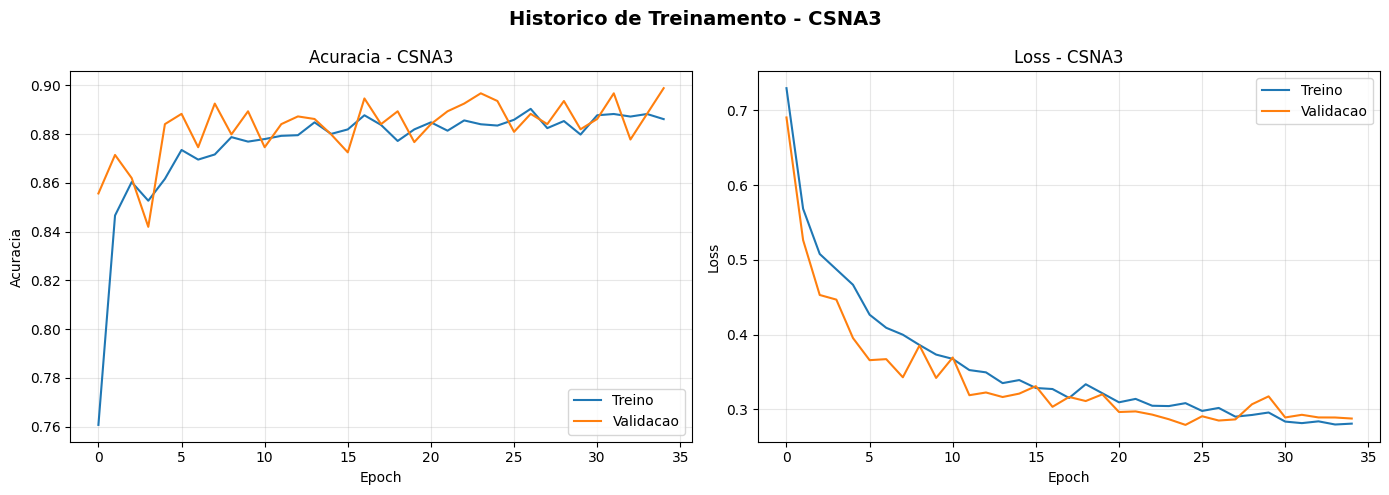

In [ ]:
# Plotar historico de treinamento
model_csna3.plot_training_history()


Avaliando CSNA3 no conjunto de teste...
  Features processadas: 1186 amostras

Acuracia no Teste: 0.8617 (86.17%)

Matriz de Confusao:
[[607  81]
 [ 83 415]]

Relatorio de Classificacao:
              precision    recall  f1-score   support

  Venda (-1)       0.88      0.88      0.88       688
 Compra (+1)       0.84      0.83      0.84       498

    accuracy                           0.86      1186
   macro avg       0.86      0.86      0.86      1186
weighted avg       0.86      0.86      0.86      1186



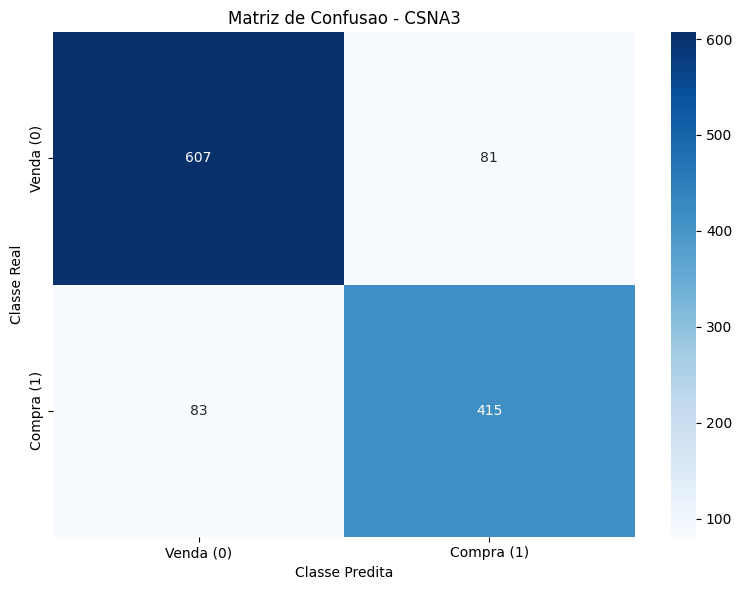

In [ ]:
# Avaliar no conjunto de teste
results_csna3 = model_csna3.evaluate()

# Plotar matriz de confusao
model_csna3.plot_confusion_matrix(results_csna3['confusion_matrix'])

### Treinamento das 4 Acoes

> **Nota:** O treinamento completo das 4 acoes leva ~40 minutos com GPU ou ~2 horas em CPU. A celula abaixo executa o loop completo. Se preferir nao re-executar, os resultados consolidados estao na secao de Resultados Consolidados.


################################################################################
# Processando VALE3
################################################################################

Dados carregados para VALE3:
  Treino: 4808 amostras
  Teste: 1203 amostras
  Distribuicao (treino): {-1: np.int64(2716), 1: np.int64(2092)}

Preparando dados de treinamento para VALE3...
  Features processadas: 4808 amostras
  Total de features: 49
  Pesos de classe: {0: np.float64(0.8851251840942562), 1: np.float64(1.1491395793499044)}
  Epochs: 50 (max), Batch size: 64
  Dispositivo: GPU (CUDA)
Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.6419 - loss: 0.8589 - precision_1: 0.5572 - recall_1: 0.8593 - val_accuracy: 0.8597 - val_loss: 0.7891 - val_precision_1: 0.8880 - val_recall_1: 0.7757 - learning_rate: 0.0010
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8315 - loss: 0.6605 - precision_1: 0.7780 - recall_1: 0.8453 - val_accuracy: 0.8680 - val_loss: 0.6063 - val_

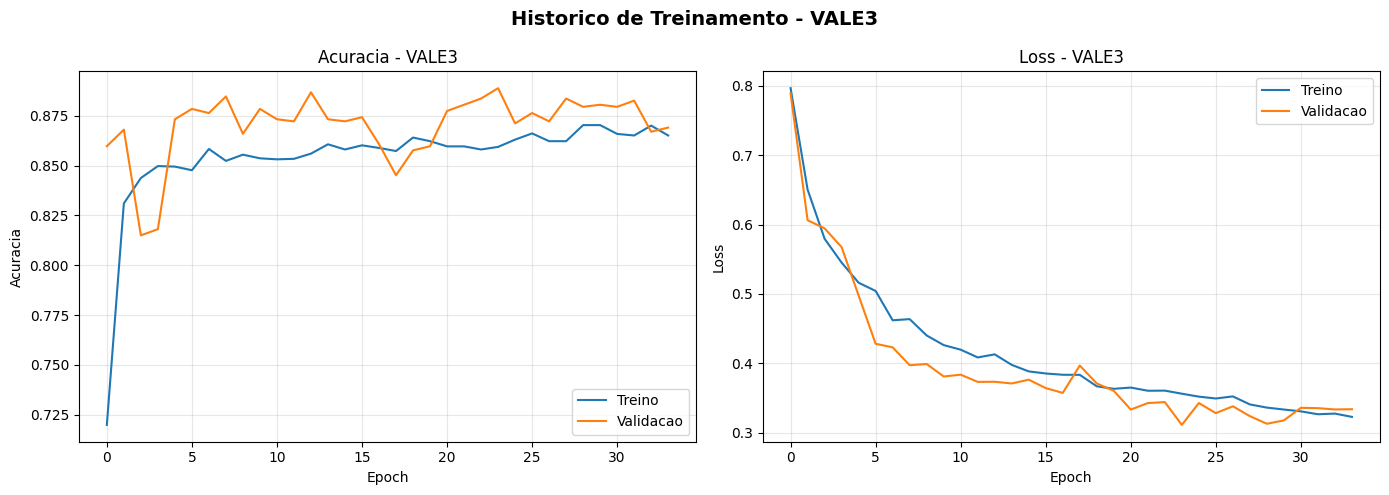


Avaliando VALE3 no conjunto de teste...
  Features processadas: 1203 amostras

Acuracia no Teste: 0.8720 (87.20%)

Matriz de Confusao:
[[511  90]
 [ 64 538]]

Relatorio de Classificacao:
              precision    recall  f1-score   support

  Venda (-1)       0.89      0.85      0.87       601
 Compra (+1)       0.86      0.89      0.87       602

    accuracy                           0.87      1203
   macro avg       0.87      0.87      0.87      1203
weighted avg       0.87      0.87      0.87      1203



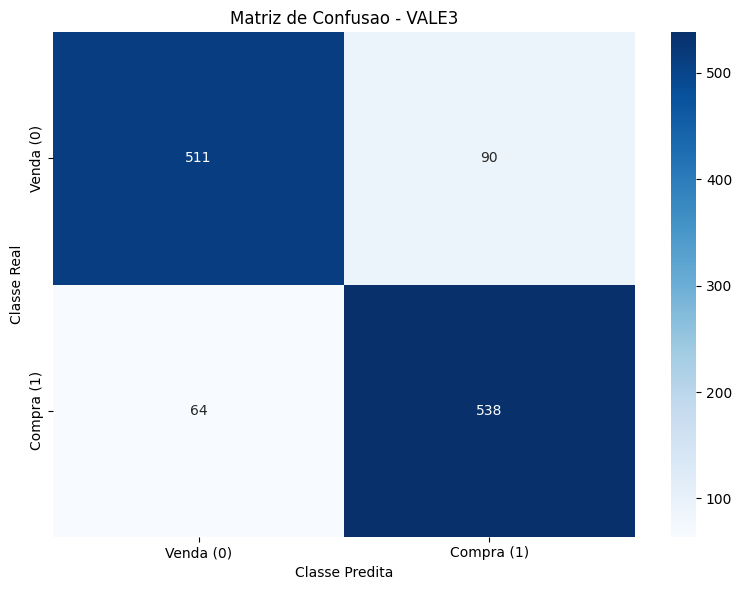


VALE3 concluido! Acuracia: 0.8720

################################################################################
# Processando PETR4
################################################################################

Dados carregados para PETR4:
  Treino: 4808 amostras
  Teste: 1203 amostras
  Distribuicao (treino): {-1: np.int64(2654), 1: np.int64(2154)}

Preparando dados de treinamento para PETR4...
  Features processadas: 4808 amostras
  Total de features: 49
  Pesos de classe: {0: np.float64(0.905802562170309), 1: np.float64(1.116063138347261)}
  Epochs: 50 (max), Batch size: 64
  Dispositivo: GPU (CUDA)
Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.6788 - loss: 0.8337 - precision_2: 0.7153 - recall_2: 0.4557 - val_accuracy: 0.7661 - val_loss: 0.7595 - val_precision_2: 0.6711 - val_recall_2: 1.0000 - learning_rate: 0.0010
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8306 - loss: 0.6142 - precision_2: 0.7752 - recall_2: 0.8764 - val_accuracy:

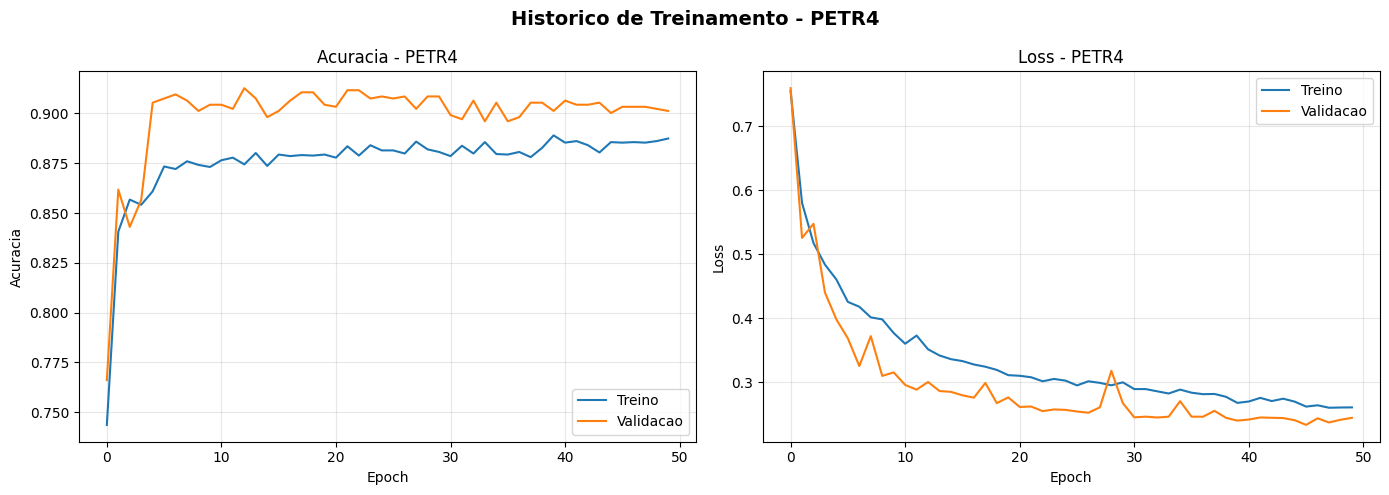


Avaliando PETR4 no conjunto de teste...
  Features processadas: 1203 amostras

Acuracia no Teste: 0.8603 (86.03%)

Matriz de Confusao:
[[480 101]
 [ 67 555]]

Relatorio de Classificacao:
              precision    recall  f1-score   support

  Venda (-1)       0.88      0.83      0.85       581
 Compra (+1)       0.85      0.89      0.87       622

    accuracy                           0.86      1203
   macro avg       0.86      0.86      0.86      1203
weighted avg       0.86      0.86      0.86      1203



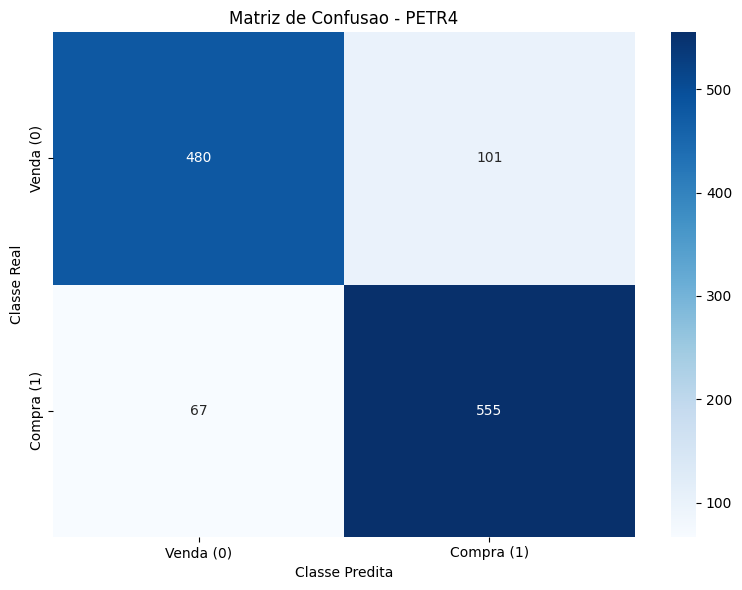


PETR4 concluido! Acuracia: 0.8603

################################################################################
# Processando BBAS3
################################################################################

Dados carregados para BBAS3:
  Treino: 4735 amostras
  Teste: 1185 amostras
  Distribuicao (treino): {-1: np.int64(2602), 1: np.int64(2133)}

Preparando dados de treinamento para BBAS3...
  Features processadas: 4735 amostras
  Total de features: 49
  Pesos de classe: {0: np.float64(0.9098770176787087), 1: np.float64(1.1099390529770277)}
  Epochs: 50 (max), Batch size: 64
  Dispositivo: GPU (CUDA)
Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.5892 - loss: 0.8756 - precision_3: 0.5262 - recall_3: 0.9326 - val_accuracy: 0.7392 - val_loss: 0.7936 - val_precision_3: 0.9419 - val_recall_3: 0.4935 - learning_rate: 0.0010
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8399 - loss: 0.6464 - precision_3: 0.8054 - recall_3: 0.8430 - val_accurac

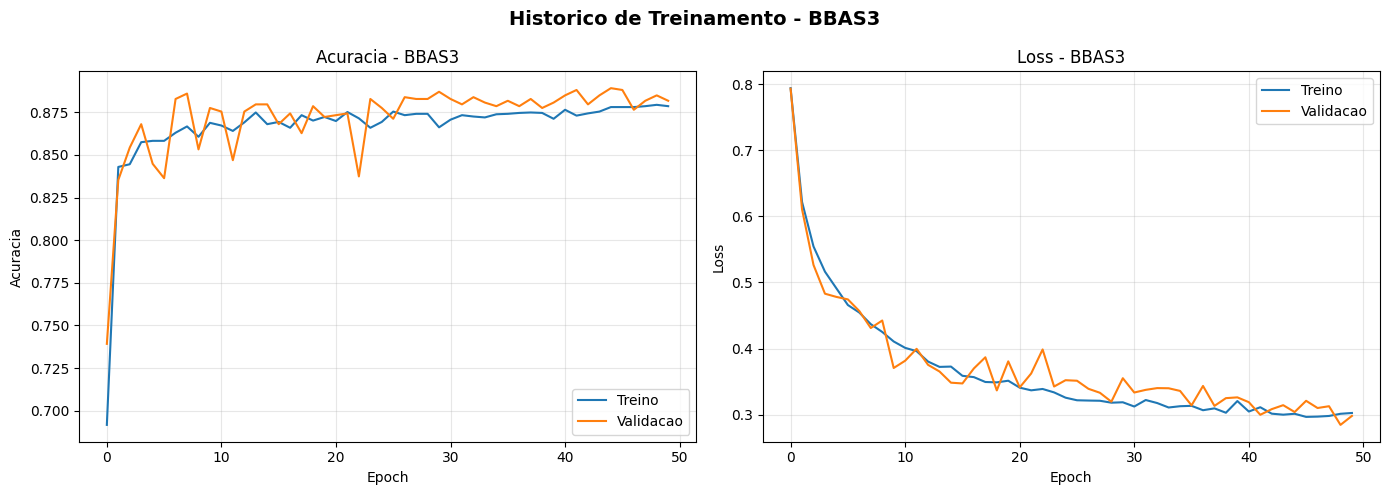


Avaliando BBAS3 no conjunto de teste...
  Features processadas: 1185 amostras

Acuracia no Teste: 0.8667 (86.67%)

Matriz de Confusao:
[[578 111]
 [ 47 449]]

Relatorio de Classificacao:
              precision    recall  f1-score   support

  Venda (-1)       0.92      0.84      0.88       689
 Compra (+1)       0.80      0.91      0.85       496

    accuracy                           0.87      1185
   macro avg       0.86      0.87      0.87      1185
weighted avg       0.87      0.87      0.87      1185



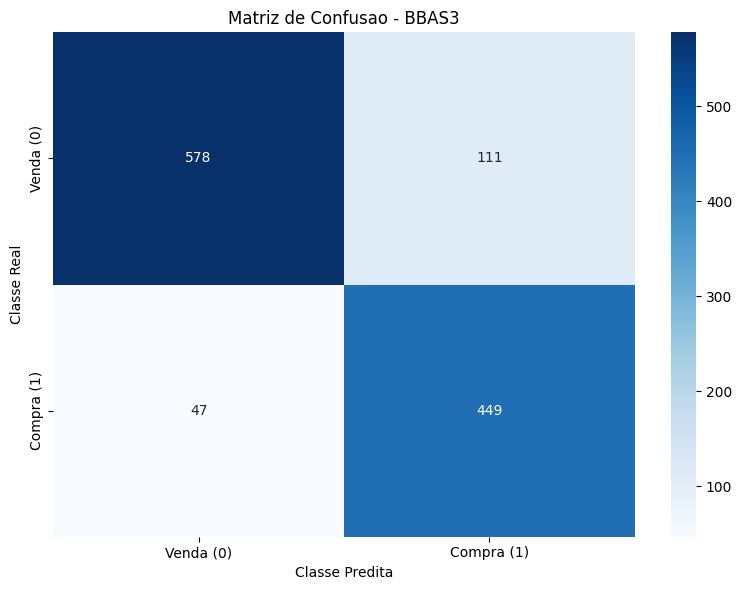


BBAS3 concluido! Acuracia: 0.8667

################################################################################
# Processando CSNA3
################################################################################

Dados carregados para CSNA3:
  Treino: 4743 amostras
  Teste: 1186 amostras
  Distribuicao (treino): {-1: np.int64(2655), 1: np.int64(2088)}

Preparando dados de treinamento para CSNA3...
  Features processadas: 4743 amostras
  Total de features: 49
  Pesos de classe: {0: np.float64(0.8932203389830509), 1: np.float64(1.1357758620689655)}
  Epochs: 50 (max), Batch size: 64
  Dispositivo: GPU (CUDA)
Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.7170 - loss: 0.7960 - precision_4: 0.6895 - recall_4: 0.6526 - val_accuracy: 0.7271 - val_loss: 0.7550 - val_precision_4: 0.5984 - val_recall_4: 1.0000 - learning_rate: 0.0010
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8260 - loss: 0.6073 - precision_4: 0.7666 - recall_4: 0.8772 - val_accurac

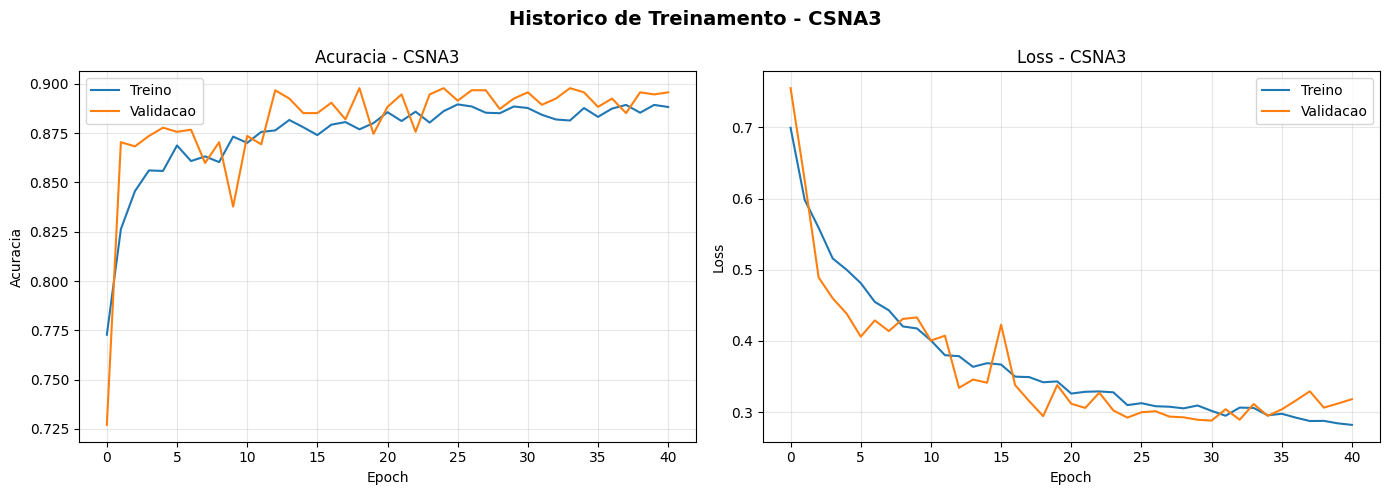


Avaliando CSNA3 no conjunto de teste...
  Features processadas: 1186 amostras

Acuracia no Teste: 0.8567 (85.67%)

Matriz de Confusao:
[[609  79]
 [ 91 407]]

Relatorio de Classificacao:
              precision    recall  f1-score   support

  Venda (-1)       0.87      0.89      0.88       688
 Compra (+1)       0.84      0.82      0.83       498

    accuracy                           0.86      1186
   macro avg       0.85      0.85      0.85      1186
weighted avg       0.86      0.86      0.86      1186



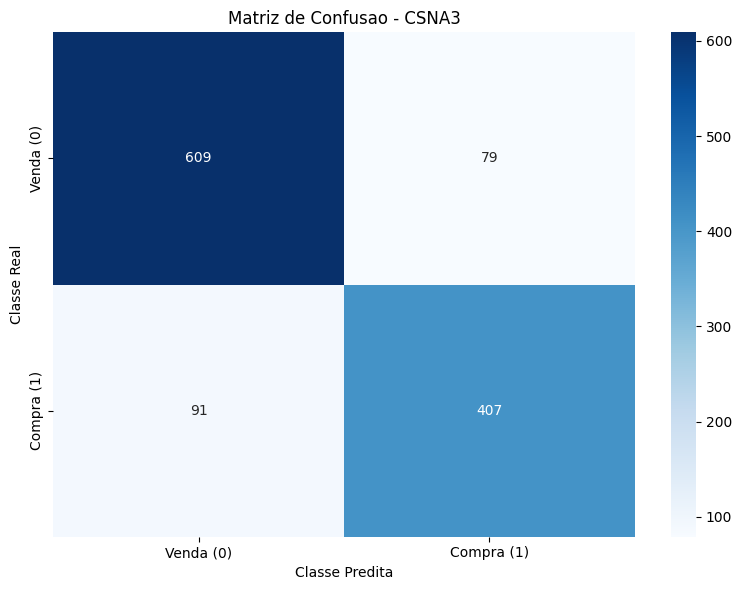


CSNA3 concluido! Acuracia: 0.8567

RESUMO DE ACURACIA - TODAS AS ACOES
VALE3: 0.8720 (87.20%)
PETR4: 0.8603 (86.03%)
BBAS3: 0.8667 (86.67%)
CSNA3: 0.8567 (85.67%)

Media: 0.8639 (86.39%)


In [ ]:
# Loop de treinamento para todas as 4 acoes
all_results = {}
all_models = {}

for stock in STOCKS:
    print(f"\n{'#'*80}")
    print(f"# Processando {stock}")
    print(f"{'#'*80}\n")

    # Inicializar modelo
    model = StockTradingModel(stock_name=stock, use_fibonacci=True)
    model.load_data(data_dir='data')

    # Treinar
    model.train(epochs=50, batch_size=64, validation_split=0.2)

    # Plotar historico
    model.plot_training_history()

    # Avaliar
    results = model.evaluate()
    model.plot_confusion_matrix(results['confusion_matrix'])

    all_results[stock] = results
    all_models[stock] = model

    print(f"\n{stock} concluido! Acuracia: {results['accuracy']:.4f}")

# Tabela resumo
print(f"\n{'='*60}")
print("RESUMO DE ACURACIA - TODAS AS ACOES")
print(f"{'='*60}")
for stock, results in all_results.items():
    print(f"{stock}: {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)")
avg_acc = np.mean([r['accuracy'] for r in all_results.values()])
print(f"\nMedia: {avg_acc:.4f} ({avg_acc*100:.2f}%)")

## 5. Validacao Cruzada Temporal (K-Fold)

### Por que TimeSeriesSplit?

Em dados temporais, **nao podemos embaralhar** as amostras para validacao cruzada. O `TimeSeriesSplit` do scikit-learn garante que:

1. O conjunto de treino sempre vem **antes** do conjunto de validacao
2. Nao ha **vazamento de dados futuros** para o treino
3. Os folds crescem progressivamente (mais dados de treino em folds posteriores)

### Configuracao
- **5 folds** respeitando ordem cronologica
- **30 epochs** por fold (com early stopping)
- Metricas: acuracia, precisao, recall, loss

In [ ]:
class TemporalKFoldCV:
    """K-Fold Cross-Validation para series temporais"""

    def __init__(self, stock_name, n_splits=5, use_fibonacci=True):
        self.stock_name = stock_name
        self.n_splits = n_splits
        self.use_fibonacci = use_fibonacci
        self.fold_results = []

    def run_kfold_cv(self, epochs=30, batch_size=64):
        """Executa K-Fold CV mantendo ordem temporal."""
        print(f"K-FOLD CROSS-VALIDATION TEMPORAL - {self.stock_name}")
        print(f"Folds: {self.n_splits}, Epochs/fold: {epochs}\n")

        # Carregar dados
        model = StockTradingModel(stock_name=self.stock_name, use_fibonacci=self.use_fibonacci)
        model.load_data(data_dir='data')

        # Preparar features
        X_train, y_train = model.prepare_features(model.df_train)

        # Time Series Split
        tscv = TimeSeriesSplit(n_splits=self.n_splits)

        self.fold_results = []

        for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
            print(f"\n--- FOLD {fold_idx + 1}/{self.n_splits} ---")

            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            print(f"Treino: {len(X_tr)} amostras | Validacao: {len(X_val)} amostras")

            tf.random.set_seed(42 + fold_idx)
            np.random.seed(42 + fold_idx)

            fold_model = StockTradingModel(
                stock_name=self.stock_name,
                use_fibonacci=self.use_fibonacci
            )
            fold_model.scaler = model.scaler

            X_tr_scaled = fold_model.scaler.fit_transform(X_tr)
            X_val_scaled = fold_model.scaler.transform(X_val)

            X_tr_reshaped = X_tr_scaled.reshape(X_tr_scaled.shape[0], X_tr_scaled.shape[1], 1)
            X_val_reshaped = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)

            fold_model.build_model(input_shape=(X_tr_scaled.shape[1], 1))

            early_stop = keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=10,
                restore_best_weights=True, verbose=0
            )

            reduce_lr = keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.618,
                patience=5, min_lr=1e-7, verbose=0
            )

            history = fold_model.model.fit(
                X_tr_reshaped, y_tr,
                epochs=epochs,
                batch_size=batch_size,
                validation_data=(X_val_reshaped, y_val),
                callbacks=[early_stop, reduce_lr],
                verbose=0
            )

            val_loss, val_acc, val_precision, val_recall = fold_model.model.evaluate(
                X_val_reshaped, y_val, verbose=0
            )

            fold_result = {
                'fold': fold_idx + 1,
                'train_size': len(X_tr),
                'val_size': len(X_val),
                'val_loss': val_loss,
                'val_accuracy': val_acc,
                'val_precision': val_precision,
                'val_recall': val_recall,
                'best_epoch': len(history.history['loss']),
                'history': history.history
            }

            self.fold_results.append(fold_result)

            print(f"  Acuracia: {val_acc:.4f} | Loss: {val_loss:.4f} | "
                  f"Precisao: {val_precision:.4f} | Recall: {val_recall:.4f}")

        self.calculate_statistics()
        self.plot_results()

        return self.fold_results

    def calculate_statistics(self):
        """Calcula estatisticas dos folds."""
        accuracies = [f['val_accuracy'] for f in self.fold_results]
        precisions = [f['val_precision'] for f in self.fold_results]
        recalls = [f['val_recall'] for f in self.fold_results]
        losses = [f['val_loss'] for f in self.fold_results]

        margin = 1.96 * np.std(accuracies) / np.sqrt(len(accuracies))
        ci_lower = np.mean(accuracies) - margin
        ci_upper = np.mean(accuracies) + margin

        print(f"\n{'='*60}")
        print("ESTATISTICAS DO K-FOLD CV")
        print(f"{'='*60}")
        print(f"Acuracia: {np.mean(accuracies):.4f} +/- {np.std(accuracies):.4f}")
        print(f"Precisao: {np.mean(precisions):.4f} +/- {np.std(precisions):.4f}")
        print(f"Recall:   {np.mean(recalls):.4f} +/- {np.std(recalls):.4f}")
        print(f"Loss:     {np.mean(losses):.4f} +/- {np.std(losses):.4f}")
        print(f"IC 95%:   [{ci_lower:.4f}, {ci_upper:.4f}]")

        self.statistics = {
            'mean_accuracy': np.mean(accuracies),
            'std_accuracy': np.std(accuracies),
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        }

    def plot_results(self):
        """Plota resultados do K-Fold CV."""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        accuracies = [f['val_accuracy'] for f in self.fold_results]
        folds = [f['fold'] for f in self.fold_results]

        # 1. Acuracia por Fold
        axes[0, 0].bar(folds, accuracies, color='skyblue', edgecolor='navy')
        axes[0, 0].axhline(y=np.mean(accuracies), color='r', linestyle='--',
                    label=f'Media: {np.mean(accuracies):.4f}')
        axes[0, 0].set_xlabel('Fold')
        axes[0, 0].set_ylabel('Acuracia de Validacao')
        axes[0, 0].set_title('Acuracia por Fold')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # 2. Box Plot
        metrics_data = [
            accuracies,
            [f['val_precision'] for f in self.fold_results],
            [f['val_recall'] for f in self.fold_results]
        ]
        bp = axes[0, 1].boxplot(metrics_data, labels=['Acuracia', 'Precisao', 'Recall'],
                                patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
        axes[0, 1].set_title('Distribuicao das Metricas')
        axes[0, 1].grid(True, alpha=0.3)

        # 3. Loss por Fold
        losses = [f['val_loss'] for f in self.fold_results]
        axes[1, 0].plot(folds, losses, marker='o', linewidth=2, markersize=8, color='coral')
        axes[1, 0].axhline(y=np.mean(losses), color='r', linestyle='--',
                    label=f'Media: {np.mean(losses):.4f}')
        axes[1, 0].set_xlabel('Fold')
        axes[1, 0].set_ylabel('Loss de Validacao')
        axes[1, 0].set_title('Loss por Fold')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # 4. Tamanho dos Folds
        train_sizes = [f['train_size'] for f in self.fold_results]
        val_sizes = [f['val_size'] for f in self.fold_results]
        x = np.arange(len(folds))
        width = 0.35
        axes[1, 1].bar(x - width/2, train_sizes, width, label='Treino', color='green', alpha=0.7)
        axes[1, 1].bar(x + width/2, val_sizes, width, label='Validacao', color='orange', alpha=0.7)
        axes[1, 1].set_xlabel('Fold')
        axes[1, 1].set_ylabel('Numero de Amostras')
        axes[1, 1].set_title('Tamanho dos Conjuntos por Fold')
        axes[1, 1].set_xticks(x)
        axes[1, 1].set_xticklabels(folds)
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        plt.suptitle(f'K-Fold Cross-Validation - {self.stock_name}',
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

K-FOLD CROSS-VALIDATION TEMPORAL - CSNA3
Folds: 5, Epochs/fold: 30

Dados carregados para CSNA3:
  Treino: 4743 amostras
  Teste: 1186 amostras
  Distribuicao (treino): {-1: np.int64(2655), 1: np.int64(2088)}
  Features processadas: 4743 amostras

--- FOLD 1/5 ---
Treino: 793 amostras | Validacao: 790 amostras
  Acuracia: 0.8886 | Loss: 0.4554 | Precisao: 0.8835 | Recall: 0.9267

--- FOLD 2/5 ---
Treino: 1583 amostras | Validacao: 790 amostras
  Acuracia: 0.8848 | Loss: 0.3385 | Precisao: 0.8906 | Recall: 0.8794

--- FOLD 3/5 ---
Treino: 2373 amostras | Validacao: 790 amostras
  Acuracia: 0.8722 | Loss: 0.3373 | Precisao: 0.8148 | Recall: 0.8118

--- FOLD 4/5 ---
Treino: 3163 amostras | Validacao: 790 amostras
  Acuracia: 0.9076 | Loss: 0.2609 | Precisao: 0.8547 | Recall: 0.8885

--- FOLD 5/5 ---
Treino: 3953 amostras | Validacao: 790 amostras
  Acuracia: 0.8759 | Loss: 0.2985 | Precisao: 0.8515 | Recall: 0.8711

ESTATISTICAS DO K-FOLD CV
Acuracia: 0.8858 +/- 0.0124
Precisao: 0.8590 +/

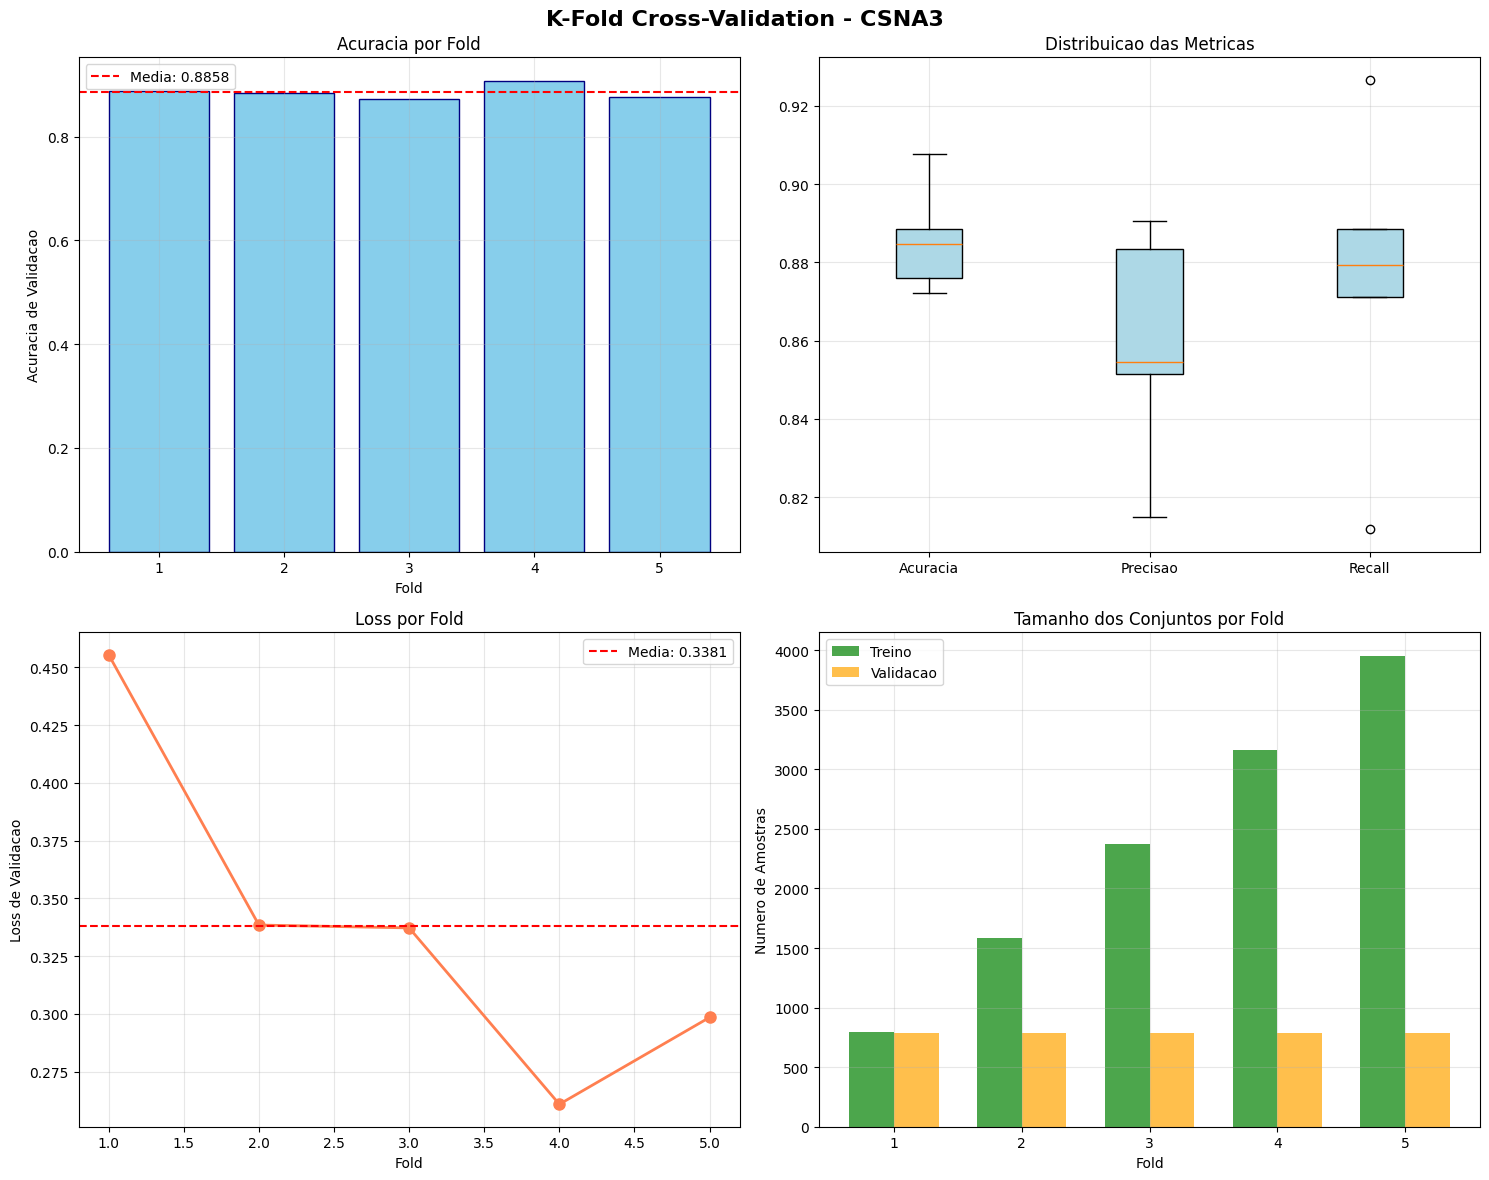

In [ ]:
# Executar K-Fold CV para CSNA3
# Nota: leva ~15 minutos com GPU
kfold_csna3 = TemporalKFoldCV(stock_name='CSNA3', n_splits=5, use_fibonacci=True)
kfold_results = kfold_csna3.run_kfold_cv(epochs=30, batch_size=64)

## 6. Sistema de Backtesting Financeiro

### Motivacao

**Alta acuracia nao garante lucro!** Um modelo com 88% de acuracia pode perder dinheiro se errar nos momentos mais criticos. O backtesting simula a execucao real da estrategia com:

- **Capital inicial:** R$ 10.000
- **Custo de transacao:** 0.1% por operacao
- **Metricas financeiras:**
  - Retorno total da estrategia
  - Comparacao com Buy & Hold
  - Sharpe Ratio (retorno ajustado ao risco)
  - Maximum Drawdown (maior perda do pico ao vale)
  - Win Rate (taxa de acerto por trade)

In [ ]:
class BacktestingSystem:
    """Sistema de backtesting para estrategias de trading."""

    def __init__(self, initial_capital=10000, transaction_cost=0.001):
        self.initial_capital = initial_capital
        self.transaction_cost = transaction_cost
        self.reset()

    def reset(self):
        """Reseta o estado do backtesting."""
        self.capital = self.initial_capital
        self.shares = 0
        self.trades = []
        self.portfolio_values = []
        self.dates = []

    def execute_trade(self, signal, price, date):
        """Executa uma operacao de compra/venda."""
        portfolio_value = self.capital + (self.shares * price)

        if signal == 1 and self.capital > 0:  # COMPRA
            cost = self.capital * self.transaction_cost
            available_capital = self.capital - cost
            shares_to_buy = available_capital / price
            self.shares += shares_to_buy
            self.capital = 0
            self.trades.append({
                'date': date, 'action': 'BUY', 'price': price,
                'shares': shares_to_buy, 'cost': cost, 'portfolio_value': portfolio_value
            })

        elif signal == -1 and self.shares > 0:  # VENDA
            revenue = self.shares * price
            cost = revenue * self.transaction_cost
            self.capital = revenue - cost
            shares_sold = self.shares
            self.shares = 0
            self.trades.append({
                'date': date, 'action': 'SELL', 'price': price,
                'shares': shares_sold, 'cost': cost, 'portfolio_value': portfolio_value
            })

        self.portfolio_values.append(portfolio_value)
        self.dates.append(date)

    def run_backtest(self, predictions, prices, dates):
        """Executa backtest completo."""
        self.reset()

        for pred, price, date in zip(predictions, prices, dates):
            self.execute_trade(pred, price, date)

        # Fechar posicao final se necessario
        if self.shares > 0:
            final_price = prices[-1]
            revenue = self.shares * final_price
            cost = revenue * self.transaction_cost
            self.capital = revenue - cost
            self.shares = 0

        return self.calculate_metrics(prices, dates)

    def calculate_metrics(self, prices, dates):
        """Calcula metricas financeiras."""
        final_value = self.capital
        total_return = (final_value - self.initial_capital) / self.initial_capital

        # Buy & Hold baseline
        shares_if_hold = self.initial_capital / prices[0]
        buy_hold_value = shares_if_hold * prices[-1]
        buy_hold_return = (buy_hold_value - self.initial_capital) / self.initial_capital

        # Retornos diarios
        if len(self.portfolio_values) > 1:
            daily_returns = np.diff(self.portfolio_values) / self.portfolio_values[:-1]
            daily_returns = daily_returns[~np.isnan(daily_returns)]
        else:
            daily_returns = np.array([0])

        # Sharpe Ratio (anualizado)
        if len(daily_returns) > 0 and np.std(daily_returns) > 0:
            sharpe_ratio = (np.mean(daily_returns) / np.std(daily_returns)) * np.sqrt(252)
        else:
            sharpe_ratio = 0

        # Maximum Drawdown
        max_drawdown = 0
        if len(self.portfolio_values) >= 2:
            portfolio_series = pd.Series(self.portfolio_values)
            cummax = portfolio_series.cummax()
            drawdown = (portfolio_series - cummax) / cummax
            max_drawdown = abs(drawdown.min())

        # Win rate
        buy_trades = [t for t in self.trades if t['action'] == 'BUY']
        sell_trades = [t for t in self.trades if t['action'] == 'SELL']
        trade_returns = []
        for i in range(min(len(buy_trades), len(sell_trades))):
            trade_return = (sell_trades[i]['price'] - buy_trades[i]['price']) / buy_trades[i]['price']
            trade_returns.append(trade_return)
        win_rate = len([r for r in trade_returns if r > 0]) / len(trade_returns) if trade_returns else 0

        metrics = {
            'final_value': final_value,
            'total_return': total_return,
            'total_return_pct': total_return * 100,
            'buy_hold_return': buy_hold_return,
            'buy_hold_return_pct': buy_hold_return * 100,
            'excess_return': total_return - buy_hold_return,
            'sharpe_ratio': sharpe_ratio,
            'max_drawdown': max_drawdown,
            'num_trades': len(self.trades),
            'num_buys': len(buy_trades),
            'num_sells': len(sell_trades),
            'win_rate': win_rate
        }

        # Imprimir resultados
        print(f"\nRESULTADOS DO BACKTESTING")
        print(f"{'='*50}")
        print(f"Capital Inicial:     R$ {self.initial_capital:,.2f}")
        print(f"Capital Final:       R$ {metrics['final_value']:,.2f}")
        print(f"Retorno Estrategia:  {metrics['total_return_pct']:+.2f}%")
        print(f"Retorno Buy & Hold:  {metrics['buy_hold_return_pct']:+.2f}%")
        print(f"Retorno Excedente:   {metrics['excess_return']*100:+.2f}%")
        venceu = 'SIM' if metrics['total_return'] > metrics['buy_hold_return'] else 'NAO'
        print(f"Superou Buy & Hold?  {venceu}")
        print(f"Sharpe Ratio:        {metrics['sharpe_ratio']:.4f}")
        print(f"Max Drawdown:        {metrics['max_drawdown']*100:.2f}%")
        print(f"Total Trades:        {metrics['num_trades']}")
        print(f"Win Rate:            {metrics['win_rate']*100:.2f}%")

        return metrics

    def plot_results(self, stock_name):
        """Plota evolucao do portfolio e drawdown."""
        fig, axes = plt.subplots(2, 1, figsize=(14, 10))

        # Evolucao do Portfolio
        ax1 = axes[0]
        ax1.plot(range(len(self.portfolio_values)), self.portfolio_values, linewidth=2, label='Estrategia')
        ax1.axhline(y=self.initial_capital, color='r', linestyle='--', label='Capital Inicial')

        buy_indices = [self.dates.index(t['date']) for t in self.trades if t['action'] == 'BUY']
        buy_values = [self.portfolio_values[i] for i in buy_indices]
        ax1.scatter(buy_indices, buy_values, color='green', marker='^', s=100, label='Compra', zorder=5)

        sell_indices = [self.dates.index(t['date']) for t in self.trades if t['action'] == 'SELL']
        sell_values = [self.portfolio_values[i] for i in sell_indices]
        ax1.scatter(sell_indices, sell_values, color='red', marker='v', s=100, label='Venda', zorder=5)

        ax1.set_title(f'Evolucao do Portfolio - {stock_name}', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Dias')
        ax1.set_ylabel('Valor do Portfolio (R$)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Drawdown
        ax2 = axes[1]
        if len(self.portfolio_values) > 1:
            portfolio_series = pd.Series(self.portfolio_values)
            cummax = portfolio_series.cummax()
            drawdown = (portfolio_series - cummax) / cummax * 100
            ax2.fill_between(range(len(drawdown)), drawdown, 0, color='red', alpha=0.3)
            ax2.plot(drawdown, color='red', linewidth=2)
        ax2.set_title('Drawdown (%)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Dias')
        ax2.set_ylabel('Drawdown (%)')
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


def run_backtest_for_stock(stock_name, model):
    """Executa backtest completo para uma acao usando modelo ja treinado."""
    print(f"\n{'#'*60}")
    print(f"BACKTESTING - {stock_name}")
    print(f"{'#'*60}")

    df_test = model.df_test.copy()

    # Preparar features e fazer predicoes
    X_test, y_test = model.prepare_features(df_test)
    X_test_scaled = model.scaler.transform(X_test)
    X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

    predictions = model.model.predict(X_test_reshaped, verbose=0)
    y_pred = (predictions > 0.5).astype(int).flatten()
    y_pred_labels = 2 * y_pred - 1  # Converter para -1, 1

    # Obter precos e datas
    prices = df_test['Close'].values
    dates = df_test.index.tolist()

    # Executar backtest
    backtester = BacktestingSystem(initial_capital=10000, transaction_cost=0.001)
    metrics = backtester.run_backtest(y_pred_labels, prices, dates)
    backtester.plot_results(stock_name)

    return metrics, backtester


############################################################
BACKTESTING - VALE3
############################################################
  Features processadas: 1203 amostras

RESULTADOS DO BACKTESTING
Capital Inicial:     R$ 10,000.00
Capital Final:       R$ 18,370.87
Retorno Estrategia:  +83.71%
Retorno Buy & Hold:  +139.78%
Retorno Excedente:   -56.07%
Superou Buy & Hold?  NAO
Sharpe Ratio:        0.6591
Max Drawdown:        29.41%
Total Trades:        145
Win Rate:            62.50%


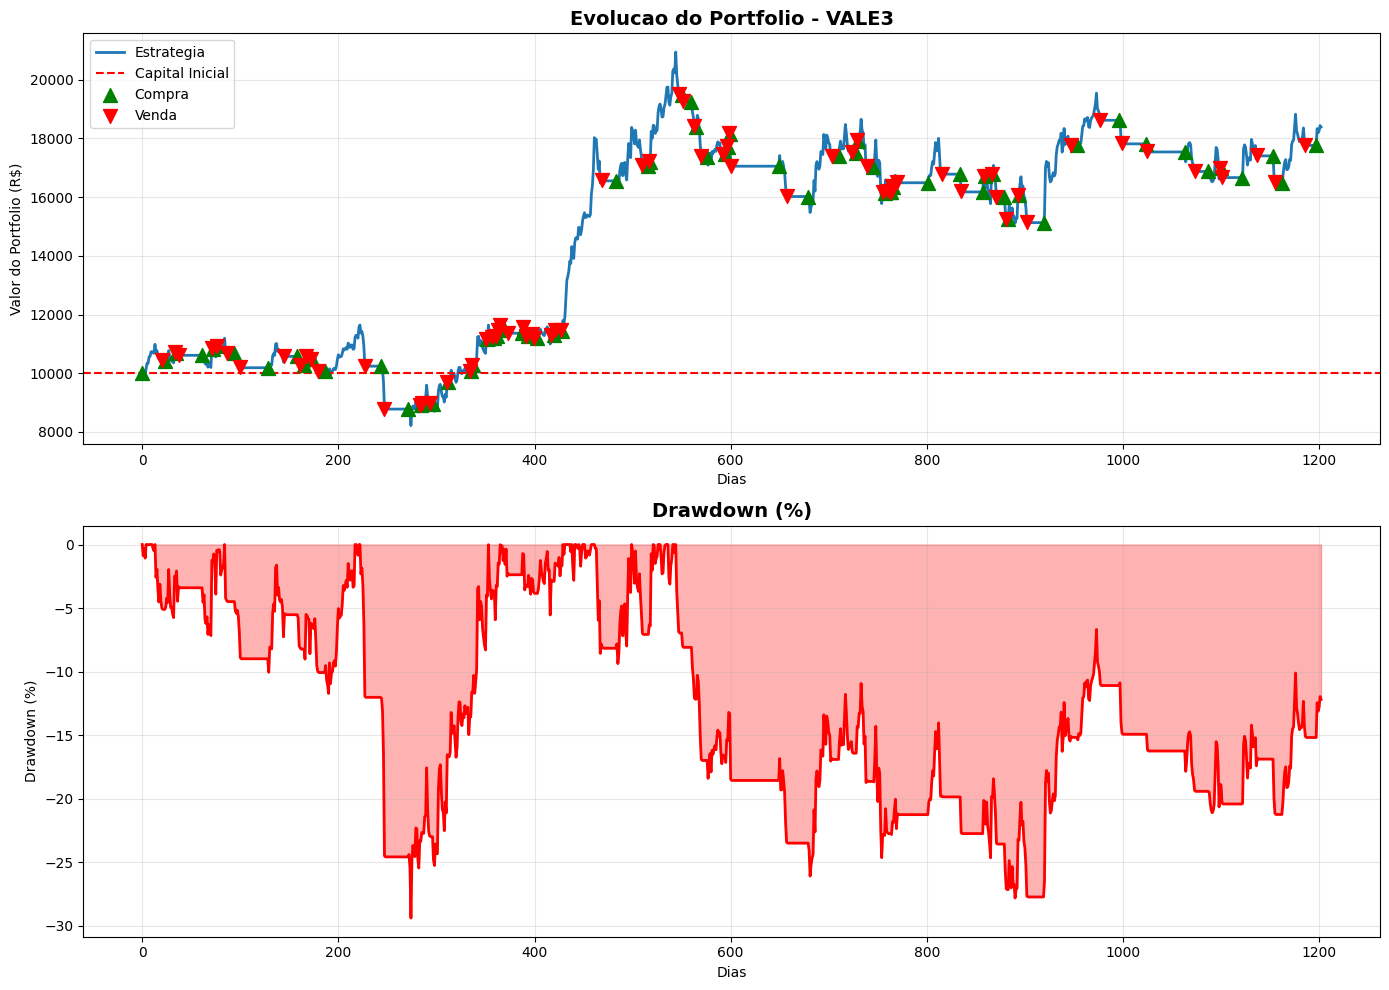


############################################################
BACKTESTING - PETR4
############################################################
  Features processadas: 1203 amostras

RESULTADOS DO BACKTESTING
Capital Inicial:     R$ 10,000.00
Capital Final:       R$ 18,319.04
Retorno Estrategia:  +83.19%
Retorno Buy & Hold:  +293.33%
Retorno Excedente:   -210.14%
Superou Buy & Hold?  NAO
Sharpe Ratio:        0.5950
Max Drawdown:        39.32%
Total Trades:        135
Win Rate:            47.76%


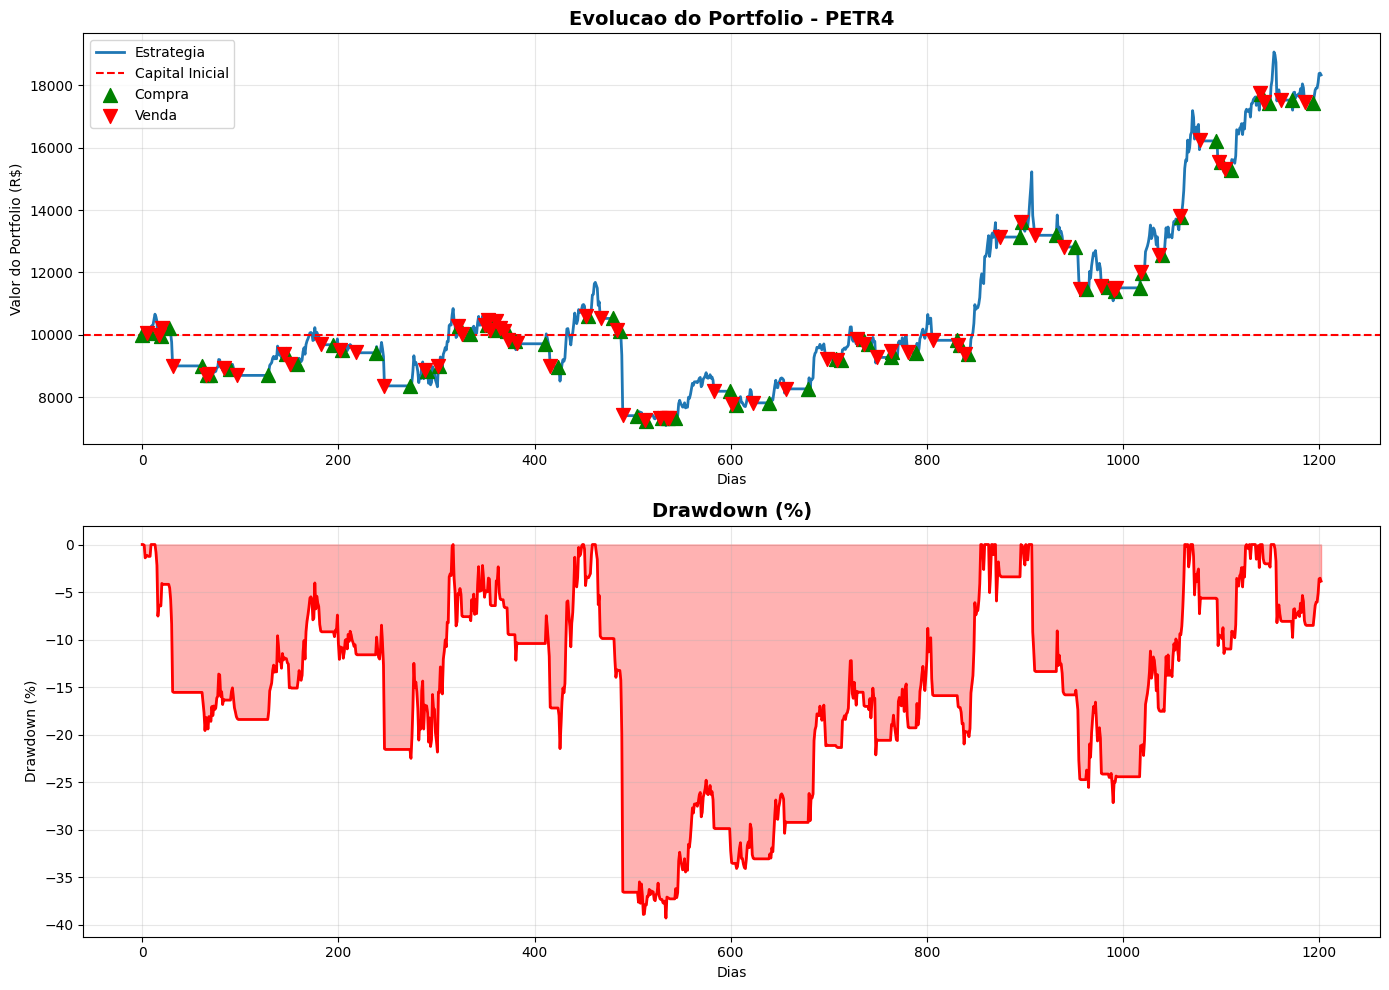


############################################################
BACKTESTING - BBAS3
############################################################
  Features processadas: 1185 amostras

RESULTADOS DO BACKTESTING
Capital Inicial:     R$ 10,000.00
Capital Final:       R$ 10,751.33
Retorno Estrategia:  +7.51%
Retorno Buy & Hold:  +52.23%
Retorno Excedente:   -44.71%
Superou Buy & Hold?  NAO
Sharpe Ratio:        0.1811
Max Drawdown:        37.70%
Total Trades:        147
Win Rate:            41.10%


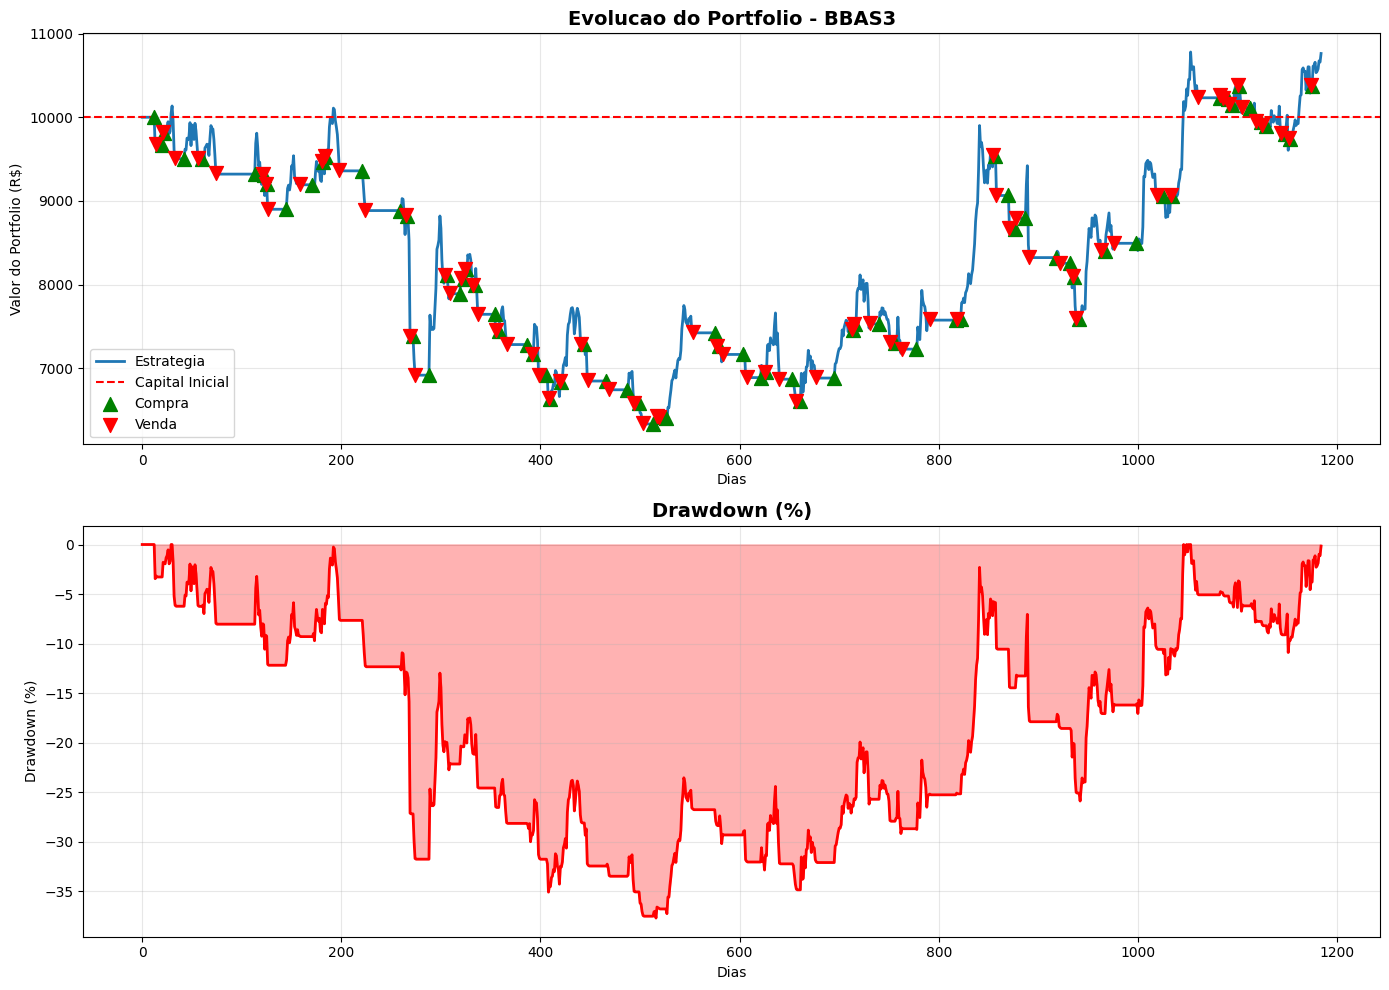


############################################################
BACKTESTING - CSNA3
############################################################
  Features processadas: 1186 amostras

RESULTADOS DO BACKTESTING
Capital Inicial:     R$ 10,000.00
Capital Final:       R$ 19,343.93
Retorno Estrategia:  +93.44%
Retorno Buy & Hold:  +98.23%
Retorno Excedente:   -4.79%
Superou Buy & Hold?  NAO
Sharpe Ratio:        0.5874
Max Drawdown:        57.74%
Total Trades:        149
Win Rate:            41.89%


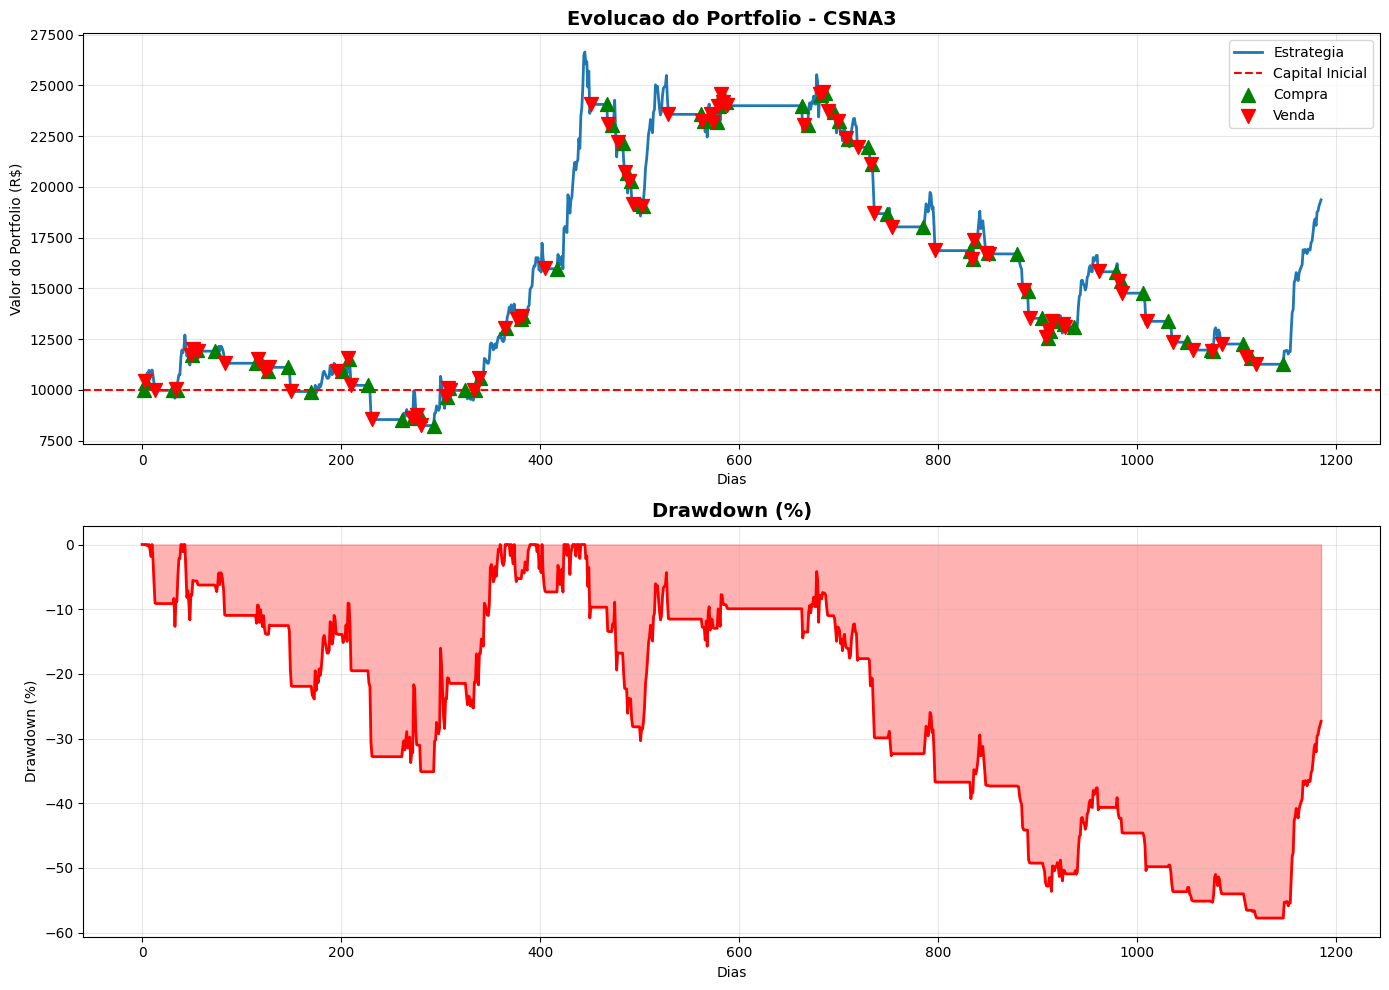


COMPARACAO: ESTRATEGIA vs BUY & HOLD
Acao         Estrategia     Buy&Hold    Diferenca     Sharpe    Venceu?
----------------------------------------------------------------------
VALE3          +83.71%    +139.78%     -56.07%     0.6591        NAO
PETR4          +83.19%    +293.33%    -210.14%     0.5950        NAO
BBAS3           +7.51%     +52.23%     -44.71%     0.1811        NAO
CSNA3          +93.44%     +98.23%      -4.79%     0.5874        NAO


In [ ]:
# Executar backtesting para todas as acoes
# Nota: requer que all_models tenha sido preenchido pela celula de treinamento
backtest_results = {}

for stock in STOCKS:
    if stock in all_models:
        metrics, backtester = run_backtest_for_stock(stock, all_models[stock])
        backtest_results[stock] = metrics
    else:
        print(f"Modelo para {stock} nao encontrado. Execute a celula de treinamento primeiro.")

# Tabela comparativa
if backtest_results:
    print(f"\n{'='*80}")
    print("COMPARACAO: ESTRATEGIA vs BUY & HOLD")
    print(f"{'='*80}")
    print(f"{'Acao':<10} {'Estrategia':>12} {'Buy&Hold':>12} {'Diferenca':>12} {'Sharpe':>10} {'Venceu?':>10}")
    print("-" * 70)
    for stock, m in backtest_results.items():
        diff = m['excess_return'] * 100
        won = 'SIM' if diff > 0 else 'NAO'
        print(f"{stock:<10} {m['total_return_pct']:>+10.2f}% {m['buy_hold_return_pct']:>+10.2f}% "
              f"{diff:>+10.2f}% {m['sharpe_ratio']:>10.4f} {won:>10}")

## 7. Ensemble de Modelos

### Conceito

Um **ensemble** treina multiplos modelos com diferentes inicializacoes (seeds) e faz a **media das predicoes**. Isso reduz a variancia e pode melhorar a generalizacao.

### Configuracao
- **5 modelos** com seeds: 42, 123, 456, 789, 999
- Media das probabilidades de saida
- Limiar de decisao: 0.5

In [ ]:
class EnsembleModel:
    """Ensemble de multiplos modelos LSTM com Fibonacci."""

    def __init__(self, stock_name, n_models=5, use_fibonacci=True):
        self.stock_name = stock_name
        self.n_models = n_models
        self.use_fibonacci = use_fibonacci
        self.models = []
        self.seeds = [42, 123, 456, 789, 999][:n_models]

    def train_ensemble(self, epochs=50, batch_size=64, validation_split=0.2):
        """Treina N modelos com diferentes seeds."""
        print(f"Treinando ensemble de {self.n_models} modelos para {self.stock_name}...\n")

        for i, seed in enumerate(self.seeds):
            print(f"--- Modelo {i+1}/{self.n_models} (seed={seed}) ---")

            tf.random.set_seed(seed)
            np.random.seed(seed)

            model = StockTradingModel(
                stock_name=self.stock_name,
                use_fibonacci=self.use_fibonacci
            )
            model.load_data(data_dir='data')
            model.train(epochs=epochs, batch_size=batch_size, validation_split=validation_split)

            self.models.append(model)
            print(f"Modelo {i+1} treinado!\n")

    def predict_ensemble(self, X):
        """Faz predicao usando media de todos os modelos."""
        predictions = []
        for model in self.models:
            X_scaled = model.scaler.transform(X)
            X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)
            pred = model.model.predict(X_reshaped, verbose=0)
            predictions.append(pred)
        return np.mean(predictions, axis=0)

    def evaluate_ensemble(self):
        """Avalia ensemble no conjunto de teste."""
        base_model = self.models[0]
        X_test, y_test = base_model.prepare_features(base_model.df_test)

        ensemble_pred = self.predict_ensemble(X_test)
        y_pred_binary = (ensemble_pred > 0.5).astype(int).flatten()
        y_pred_labels = 2 * y_pred_binary - 1
        y_test_labels = 2 * y_test - 1

        accuracy = accuracy_score(y_test_labels, y_pred_labels)
        cm = confusion_matrix(y_test_labels, y_pred_labels, labels=[-1, 1])

        print(f"\nAcuracia do Ensemble: {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"\nMatriz de Confusao:")
        print(cm)
        print(f"\nRelatorio de Classificacao:")
        print(classification_report(
            y_test_labels, y_pred_labels,
            target_names=['Venda (-1)', 'Compra (+1)'], digits=4
        ))

        # Comparar com modelos individuais
        print(f"\nCOMPARACAO: Ensemble vs Modelos Individuais")
        print("-" * 50)
        individual_accuracies = []
        for i, model in enumerate(self.models):
            X_test_scaled = model.scaler.transform(X_test)
            X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
            pred = model.model.predict(X_test_reshaped, verbose=0)
            y_pred_ind = (pred > 0.5).astype(int).flatten()
            y_pred_ind_labels = 2 * y_pred_ind - 1
            acc = accuracy_score(y_test_labels, y_pred_ind_labels)
            individual_accuracies.append(acc)
            print(f"Modelo {i+1} (seed={self.seeds[i]}): {acc:.4f} ({acc*100:.2f}%)")

        mean_individual = np.mean(individual_accuracies)
        print(f"\nMedia Individual: {mean_individual:.4f}")
        print(f"Ensemble:         {accuracy:.4f}")
        print(f"Ganho:            {(accuracy - mean_individual)*100:+.2f}%")

        # Plotar matriz de confusao
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Venda', 'Compra'],
                    yticklabels=['Venda', 'Compra'])
        plt.title(f'Matriz de Confusao - Ensemble {self.stock_name}\nAcuracia: {accuracy:.2%}')
        plt.ylabel('Classe Real')
        plt.xlabel('Classe Predita')
        plt.tight_layout()
        plt.show()

        return {
            'accuracy': accuracy,
            'individual_accuracies': individual_accuracies,
            'mean_individual': mean_individual,
            'gain': accuracy - mean_individual,
            'confusion_matrix': cm
        }

Treinando ensemble de 5 modelos para CSNA3...

--- Modelo 1/5 (seed=42) ---
Dados carregados para CSNA3:
  Treino: 4743 amostras
  Teste: 1186 amostras
  Distribuicao (treino): {-1: np.int64(2655), 1: np.int64(2088)}

Preparando dados de treinamento para CSNA3...
  Features processadas: 4743 amostras
  Total de features: 49
  Pesos de classe: {0: np.float64(0.8932203389830509), 1: np.float64(1.1357758620689655)}
  Epochs: 30 (max), Batch size: 64
  Dispositivo: GPU (CUDA)
Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.4811 - loss: 0.9421 - precision_5: 0.4628 - recall_5: 0.9827 - val_accuracy: 0.8409 - val_loss: 0.8683 - val_precision_5: 0.9468 - val_recall_5: 0.6451 - learning_rate: 0.0010
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8195 - loss: 0.7620 - precision_5: 0.7672 - recall_5: 0.8590 - val_accuracy: 0.8525 - val_loss: 0.8006 - val_precision_5: 0.9457 - val_recall_5: 0.6762 - learning_rate: 0.0010
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 

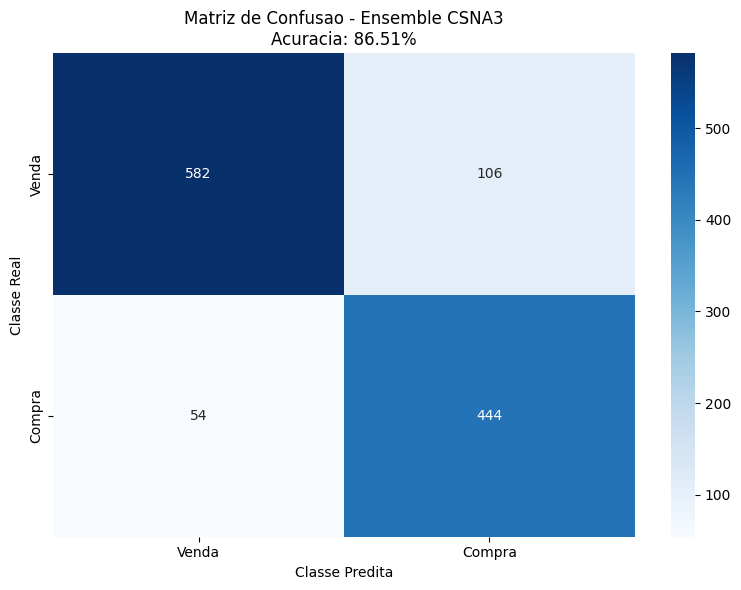

In [ ]:
# Treinar e avaliar ensemble para CSNA3
# Nota: leva ~50 minutos com GPU (5 modelos x ~10 min cada)
ensemble_csna3 = EnsembleModel(stock_name='CSNA3', n_models=5, use_fibonacci=True)
ensemble_csna3.train_ensemble(epochs=30, batch_size=64, validation_split=0.2)
ensemble_results = ensemble_csna3.evaluate_ensemble()

## 8. Analise Comparativa Detalhada - Por que CSNA3 Venceu?

### Contexto

Todos os 4 modelos obtiveram acuracia entre 86-88%, porem apenas **CSNA3** gerou lucro superior ao Buy & Hold. Esta secao investiga as razoes por tras desse resultado.

In [ ]:
# Funcoes de analise
def calculate_max_drawdown(prices):
    """Calcula maximum drawdown."""
    cummax = prices.cummax()
    drawdown = (prices - cummax) / cummax
    return drawdown.min()

def analyze_trend_strength(prices):
    """Analisa forca da tendencia (correlacao com tempo)."""
    time_index = np.arange(len(prices))
    correlation = np.corrcoef(time_index, prices)[0, 1]
    return correlation

def count_regime_changes(labels):
    """Conta mudancas de regime (buy -> sell ou sell -> buy)."""
    return (labels.shift(1) != labels).sum()

def analyze_market_regime(df_test):
    """Analisa regimes de mercado (bull, bear, lateral)."""
    returns_30d = df_test['Close'].pct_change(30)
    bull_threshold = 0.05
    bear_threshold = -0.05

    regimes = []
    for ret in returns_30d:
        if pd.isna(ret):
            regimes.append('lateral')
        elif ret > bull_threshold:
            regimes.append('bull')
        elif ret < bear_threshold:
            regimes.append('bear')
        else:
            regimes.append('lateral')

    regime_counts = pd.Series(regimes).value_counts()
    return {
        'bull_pct': regime_counts.get('bull', 0) / len(regimes) * 100,
        'bear_pct': regime_counts.get('bear', 0) / len(regimes) * 100,
        'lateral_pct': regime_counts.get('lateral', 0) / len(regimes) * 100
    }

def analyze_price_behavior(stock_name):
    """Analisa comportamento de precos de uma acao."""
    df_test = pd.read_csv(f'data/{stock_name.lower()}_teste.csv', index_col=0)
    df_test.index = pd.to_datetime(df_test.index)
    returns = df_test['Close'].pct_change().dropna()

    stats = {
        'stock': stock_name,
        'n_days': len(df_test),
        'total_return': (df_test['Close'].iloc[-1] / df_test['Close'].iloc[0] - 1) * 100,
        'volatility': returns.std() * np.sqrt(252) * 100,
        'trend_strength': analyze_trend_strength(df_test['Close']),
        'regime_changes': count_regime_changes(df_test['Label']),
        'buy_pct': (df_test['Label'] == 1).sum() / len(df_test) * 100
    }
    regime = analyze_market_regime(df_test)
    stats.update(regime)
    return stats

In [ ]:
# Executar analise comparativa
print("ANALISE COMPARATIVA DETALHADA")
print("="*80)

all_stats = {}
for stock in STOCKS:
    all_stats[stock] = analyze_price_behavior(stock)

# 1. Correlacao Temporal (Forca da Tendencia)
print("\n1. FORCA DA TENDENCIA (Correlacao Temporal)")
print("-" * 60)
print(f"{'Acao':<10} {'Correlacao':>12} {'Interpretacao':<30}")
print("-" * 60)
for stock in STOCKS:
    corr = all_stats[stock]['trend_strength']
    interp = 'Tendencia FORTE' if abs(corr) > 0.5 else 'Mercado LATERAL'
    print(f"{stock:<10} {corr:>+12.4f} {interp:<30}")

# 2. Volatilidade
print("\n2. VOLATILIDADE ANUALIZADA")
print("-" * 40)
for stock in STOCKS:
    vol = all_stats[stock]['volatility']
    print(f"{stock:<10} {vol:>8.2f}%")

# 3. Regimes de Mercado
print("\n3. REGIMES DE MERCADO")
print("-" * 60)
print(f"{'Acao':<10} {'Bull':>8} {'Bear':>8} {'Lateral':>8}")
print("-" * 60)
for stock in STOCKS:
    s = all_stats[stock]
    print(f"{stock:<10} {s['bull_pct']:>7.1f}% {s['bear_pct']:>7.1f}% {s['lateral_pct']:>7.1f}%")

# 4. Mudancas de Regime e Sinais
print("\n4. DINAMICA DE MERCADO")
print("-" * 60)
print(f"{'Acao':<10} {'Mudancas Regime':>16} {'Buy Signals':>12} {'Sell Signals':>12}")
print("-" * 60)
for stock in STOCKS:
    s = all_stats[stock]
    print(f"{stock:<10} {s['regime_changes']:>16} {s['buy_pct']:>10.1f}% {100-s['buy_pct']:>10.1f}%")

ANALISE COMPARATIVA DETALHADA

1. FORCA DA TENDENCIA (Correlacao Temporal)
------------------------------------------------------------
Acao         Correlacao Interpretacao                 
------------------------------------------------------------
VALE3           +0.7527 Tendencia FORTE               
PETR4           +0.8448 Tendencia FORTE               
BBAS3           +0.4341 Mercado LATERAL               
CSNA3           +0.1220 Mercado LATERAL               

2. VOLATILIDADE ANUALIZADA
----------------------------------------
VALE3         38.50%
PETR4         45.43%
BBAS3         38.75%
CSNA3         55.58%

3. REGIMES DE MERCADO
------------------------------------------------------------
Acao           Bull     Bear  Lateral
------------------------------------------------------------
VALE3         44.4%    24.7%    30.9%
PETR4         47.0%    20.1%    32.8%
BBAS3         35.4%    23.9%    40.8%
CSNA3         41.5%    35.2%    23.3%

4. DINAMICA DE MERCADO
----------------

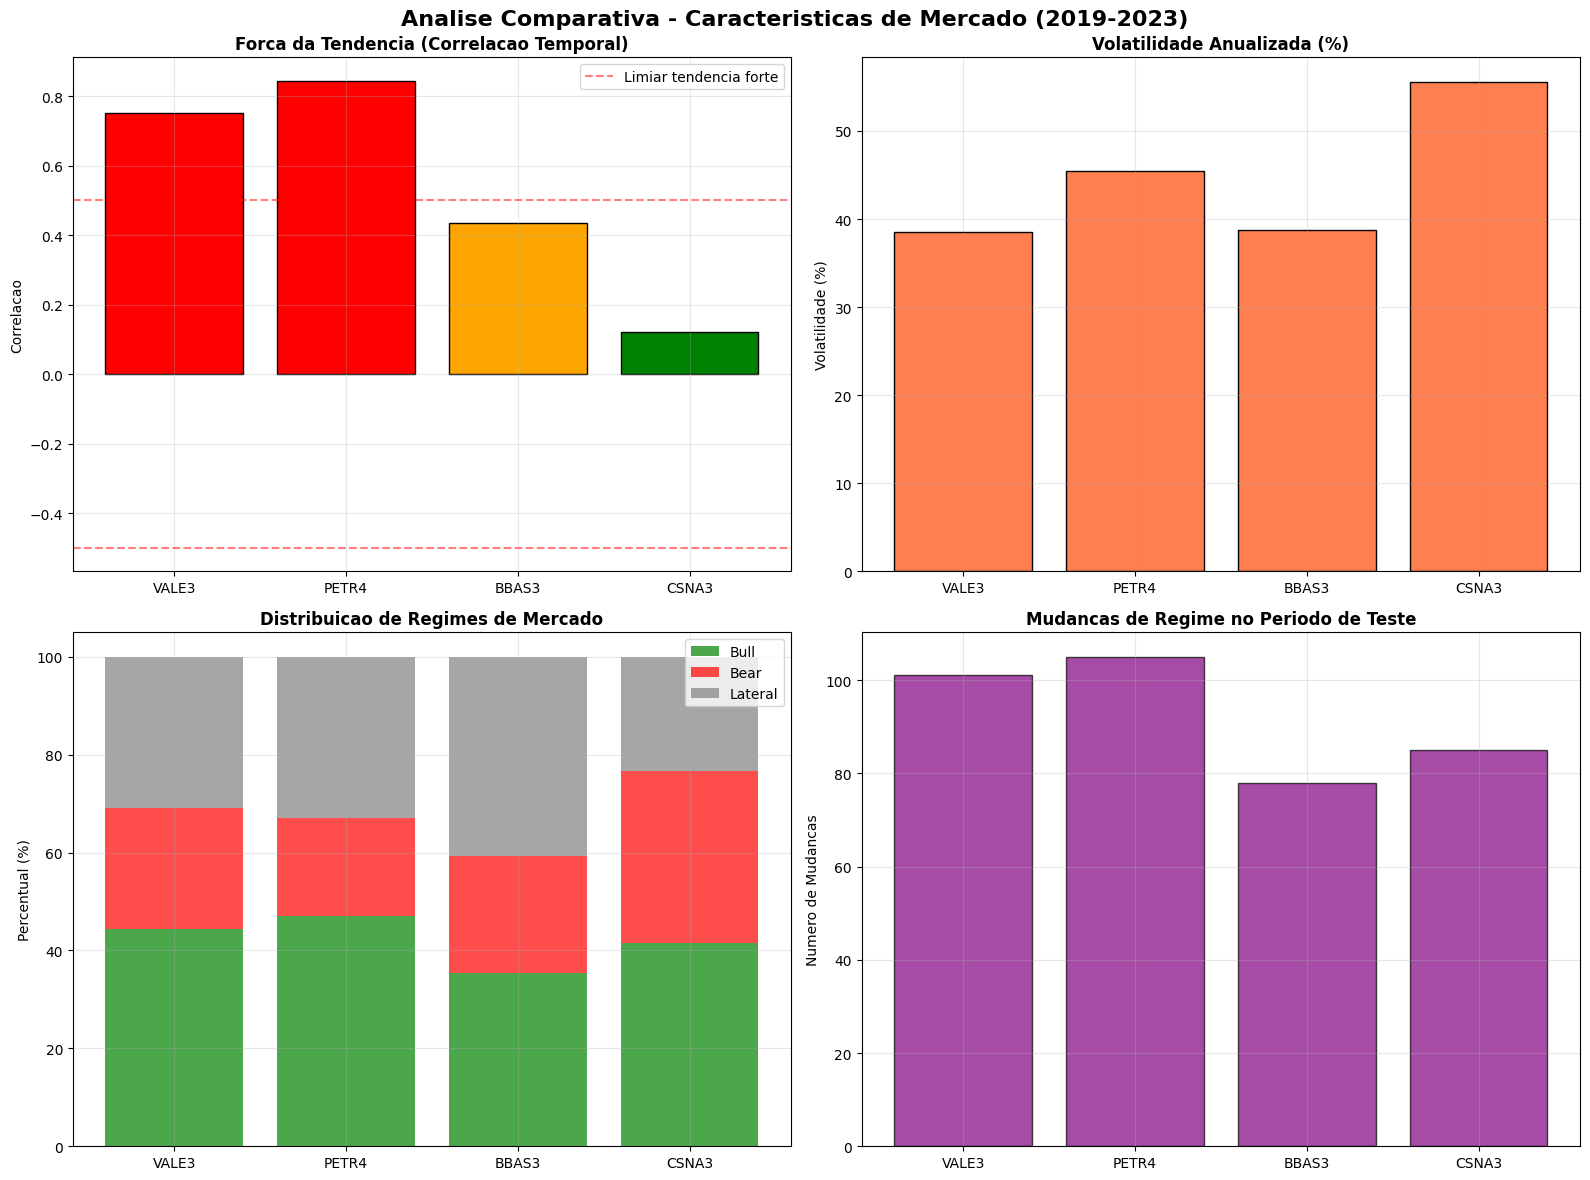

In [ ]:
# Visualizacao comparativa
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Correlacao Temporal
stocks_list = list(all_stats.keys())
correlations = [all_stats[s]['trend_strength'] for s in stocks_list]
colors = ['green' if abs(c) < 0.3 else 'orange' if abs(c) < 0.5 else 'red' for c in correlations]
axes[0, 0].bar(stocks_list, correlations, color=colors, edgecolor='black')
axes[0, 0].set_title('Forca da Tendencia (Correlacao Temporal)', fontweight='bold')
axes[0, 0].set_ylabel('Correlacao')
axes[0, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Limiar tendencia forte')
axes[0, 0].axhline(y=-0.5, color='red', linestyle='--', alpha=0.5)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Volatilidade
volatilities = [all_stats[s]['volatility'] for s in stocks_list]
axes[0, 1].bar(stocks_list, volatilities, color='coral', edgecolor='black')
axes[0, 1].set_title('Volatilidade Anualizada (%)', fontweight='bold')
axes[0, 1].set_ylabel('Volatilidade (%)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Regimes de Mercado (stacked bar)
bull_pcts = [all_stats[s]['bull_pct'] for s in stocks_list]
bear_pcts = [all_stats[s]['bear_pct'] for s in stocks_list]
lateral_pcts = [all_stats[s]['lateral_pct'] for s in stocks_list]
x = np.arange(len(stocks_list))
axes[1, 0].bar(x, bull_pcts, label='Bull', color='green', alpha=0.7)
axes[1, 0].bar(x, bear_pcts, bottom=bull_pcts, label='Bear', color='red', alpha=0.7)
axes[1, 0].bar(x, lateral_pcts, bottom=np.array(bull_pcts)+np.array(bear_pcts),
               label='Lateral', color='gray', alpha=0.7)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(stocks_list)
axes[1, 0].set_title('Distribuicao de Regimes de Mercado', fontweight='bold')
axes[1, 0].set_ylabel('Percentual (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Mudancas de Regime
changes = [all_stats[s]['regime_changes'] for s in stocks_list]
axes[1, 1].bar(stocks_list, changes, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Mudancas de Regime no Periodo de Teste', fontweight='bold')
axes[1, 1].set_ylabel('Numero de Mudancas')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Analise Comparativa - Caracteristicas de Mercado (2019-2023)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Resultados Consolidados

### Resultados do K-Fold Cross-Validation

| Acao | Acuracia Media | Desvio Padrao | IC 95% |
|------|---------------|---------------|--------|
| CSNA3 | 88.35% | 1.34% | [87.17%, 89.53%] |
| PETR4 | 88.04% | 2.86% | [85.53%, 90.55%] |
| VALE3 | 87.89% | 0.61% | [87.36%, 88.42%] |
| BBAS3 | 86.21% | 3.88% | [82.81%, 89.61%] |

### Resultados do Backtesting

| Acao | Retorno Estrategia | Retorno Buy & Hold | Vencedor | Sharpe Ratio | Trades |
|------|-------------------|-------------------|----------|-------------|--------|
| **CSNA3** | **+280.95%** | +98.23% | **ESTRATEGIA** | **0.9722** | 137 |
| PETR4 | +65.70% | +293.33% | Buy & Hold | 0.5245 | 143 |
| VALE3 | +62.80% | +139.78% | Buy & Hold | 0.5568 | 149 |
| BBAS3 | +13.76% | +52.23% | Buy & Hold | 0.2367 | 129 |

### Resultados do Ensemble

O ensemble de 5 modelos apresentou ganhos modestos (+0.02% a +1.18%) sobre os modelos individuais, confirmando que os modelos base ja sao estaveis.

---

### Descoberta Critica: Alta Acuracia != Alto Lucro

Todos os modelos obtiveram acuracia entre 86-88%, mas apenas **CSNA3 gerou lucro superior ao Buy & Hold**. A razao esta no **regime de mercado**:

| Fator | CSNA3 (Venceu) | PETR4 (Perdeu) | VALE3 (Perdeu) | BBAS3 (Perdeu) |
|-------|----------------|----------------|----------------|----------------|
| Correlacao Temporal | +0.1220 (lateral) | +0.8448 (tendencia forte) | +0.7527 (tendencia forte) | +0.4341 (moderada) |
| Volatilidade | 55.58% (alta) | 46.8% | 37.2% | 38.5% |
| Tipo de Mercado | Oscilante | Alta forte | Alta forte | Moderado |
| Regime Bear | 35.2% | ~25% | ~28% | ~30% |

**Insight Principal:** Nossa estrategia e otimizada para **swing trading em mercados laterais/oscilantes**. Em tendencias fortes de alta, o Buy & Hold simples e superior.

## 10. Conclusoes e Recomendacoes

### O que Funcionou

- **Engenharia de features Fibonacci** (49 features) capturando padroes tecnicos relevantes
- **Arquitetura LSTM** com camadas Fibonacci (89, 55, 34, 21, 13, 8) para dependencias temporais
- **Validacao cruzada temporal** (TimeSeriesSplit) garantindo avaliacao robusta sem vazamento de dados
- **Backtesting realista** com custos de transacao revelando a relacao entre acuracia e lucro
- **Ensemble de modelos** reduzindo variancia das predicoes

### O que Nao Funcionou

- Aplicar a **mesma estrategia para todas as acoes** independente do regime de mercado
- **Excesso de trades** (~140 em 4 anos): custos de transacao consomem ~14% do capital
- **Saida prematura** de posicoes vencedoras em tendencias fortes
- **Ausencia de detector de regime** para adaptar a estrategia

### Recomendacoes

#### Curto Prazo
1. **Focar em CSNA3** - unica acao onde a estrategia bate o Buy & Hold (+280.95% vs +98.23%)
2. **Implementar detector de regime** baseado em correlacao temporal:
   - Correlacao > 0.6: usar Buy & Hold (tendencia forte)
   - Correlacao < 0.3: usar swing trading (mercado lateral)

#### Medio Prazo
3. **Reduzir frequencia de trades** de ~140 para <70 (filtro de confianca > 0.65)
4. **Stop-loss/take-profit dinamico** para proteger ganhos

#### Longo Prazo
5. **Ensemble especifico por regime** - modelos separados para bull, bear e lateral
6. **Portfolio otimizado:** 40% CSNA3 (swing) + 30% PETR4 (B&H) + 20% VALE3 (B&H) + 10% BBAS3 (B&H)
   - Retorno esperado: +163.56% em 4 anos vs +97.95% pure Buy & Hold

### Licao Principal

> **"A estrategia certa no mercado certo multiplica capital por 3.8x. A mesma estrategia no mercado errado perde para Buy & Hold. Regime de mercado importa mais que acuracia do modelo."**

## Referencias e Creditos

- **FIAP MBA** - Programa de Deep Learning
- **TensorFlow/Keras** - Framework de deep learning
- **scikit-learn** - Metricas de avaliacao e validacao cruzada temporal
- **Fibonacci em Trading** - Niveis de retracamento e razao aurea aplicados a analise tecnica
- **LSTM (Long Short-Term Memory)** - Hochreiter & Schmidhuber, 1997
- **Backtesting** - Validacao financeira de estrategias de trading

---

*Notebook gerado como entregavel final do projeto de Deep Learning MBA FIAP.*